# Ужасы линейной регрессии

In [89]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    HuberRegressor,
    LinearRegression,
    RANSACRegressor,
    TheilSenRegressor,
)
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
np.random.seed(42)

# Разминка
1) Какие признаки может обработать линейная регрессия?
2) Почему нет понятия полиномиальных моделей?
3) Вам дан набор данных из 8 элементов. Вы используете стохастический градиентный спуск с батчем 8. Сколько шагов нужно сделать, чтобы пройти весь набор данных?
4) Вам нужно предсказать, к какой категории относится товар. Всего категорий 100. Как лучше решать такую задачу - через регрессию или классификацию?
5) Вам нужно предсказать, в каком часу была сделана покупка некоторого товара. Вы решили использовать для этого регрессию. Расскажите, как вы будете решать эту задачу. Как вы сформируете таргет? Как будете выдавать предсказания на инференсе?
6) Как выглядит точное решение задачи линейной регрессии (нормальная форма)?

# База
Напомню, что линейная регрессия - это модель следующего вида:
    $$a(x) = \langle w, x \rangle + w_0$$,
    где $w \in \mathbb{R}^d$, $w_0 \in \mathbb{R}$. 
Обучить линейную регрессию - значит найти $w$ и $w_0$., минимизирующие разницу между предсказанными значениями  $y'$ и  $y$.

# Ловушки в данных

Рассмотрим набор данных, состоящий из 2 разных предикторов и четырех таргетов. Этот набор специально создан, чтобы показать важность анализа данных даже в, казалось бы, простой ситуации. Построим 4 разные модели по парам (x123, y1), (x123, y2),(x123, y3), (x4, y4).

In [90]:
data_path = "D:\data\ml"

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\maksc\AppData\Local\Temp\ipykernel_3480\3547680673.py:1: SyntaxWarning: invalid escape sequence '\d'
  data_path = "D:\data\ml"


In [91]:
quartet_df = pd.read_csv(f"{data_path}/Anscombe_quartet_data.csv")

Для начала рассмотрим значения корреляций между признаками и таргетами

In [92]:
def corrplot(d: pd.DataFrame) -> None:
  corr = d.corr()
  mask = np.triu(np.ones_like(corr, dtype=bool))
  figsize = (min(d.shape[1], 11), min(d.shape[1], 9))
  f, ax = plt.subplots(figsize=figsize)
  cmap = sns.diverging_palette(230, 20, as_cmap=True)
  sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
              square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

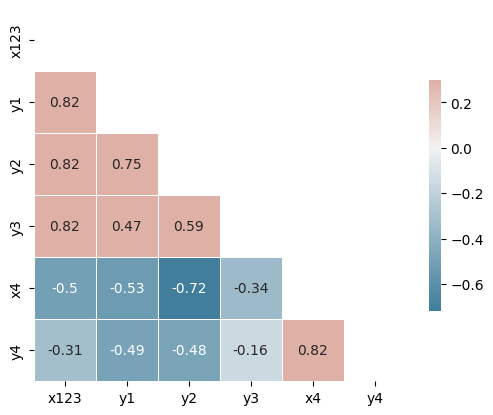

In [93]:
corrplot(quartet_df)

Как видно, корреляции одинаковы. Однако, если построить модели и графики предсказаний, результаты будут знгачительно отличаться.
Также выведем значения коэффициентов модели.

**Задание**: Постройте линейные модели для каждого из наборов данных, не смотря на графики. Отличаются ли модели?

In [94]:
def fit_and_plot_anscombe(x_series, y_series, title):
    x = np.array(x_series).reshape((-1, 1))
    y = np.array(y_series)
    model = LinearRegression().fit(
        x, y
    )
    y_pred = model.predict(x)
    r_sq = model.score(x, y)
    
    print(f"{title}")
    print(f"R²: {r_sq:.4f}")
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"Slope: {model.coef_[0]:.4f}\n")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color="green", alpha=0.7)
    plt.plot(x, y_pred, color="blue", linewidth=2)
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return model

Anscombe 1
R²: 0.6665
Intercept: 3.0001
Slope: 0.5001



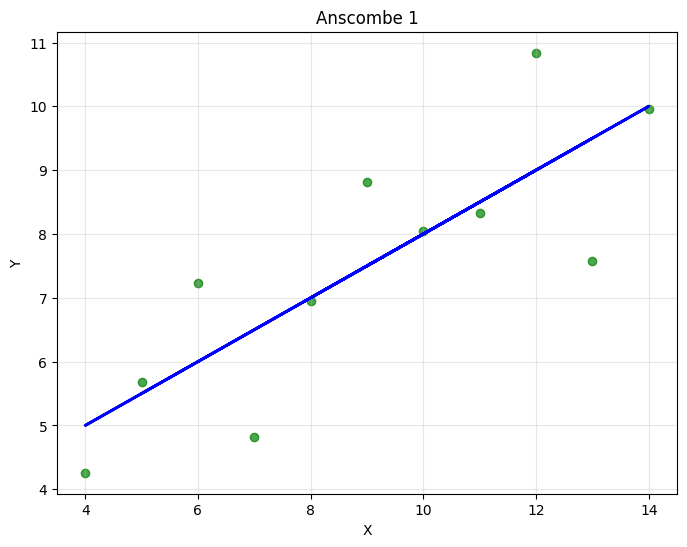

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
fit_and_plot_anscombe(quartet_df['x123'], quartet_df['y1'], "Anscombe 1")

Anscombe 2
R²: 0.6662
Intercept: 3.0009
Slope: 0.5000



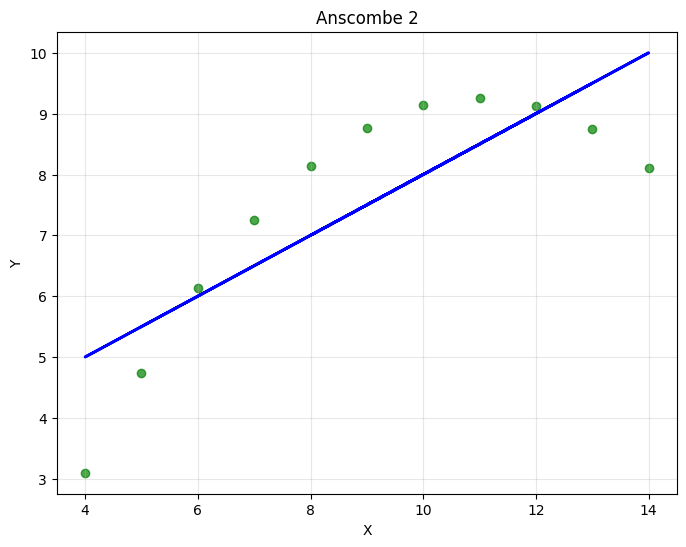

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
# Anscombe 2
fit_and_plot_anscombe(quartet_df['x123'], quartet_df['y2'], "Anscombe 2")

Anscombe 3
R²: 0.6663
Intercept: 3.0025
Slope: 0.4997



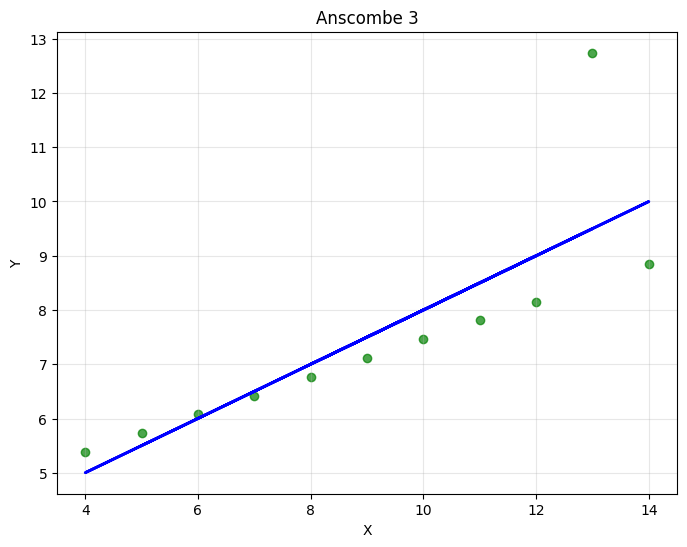

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
fit_and_plot_anscombe(quartet_df['x123'], quartet_df['y3'], "Anscombe 3")

Anscombe 3
R²: 0.6667
Intercept: 3.0017
Slope: 0.4999



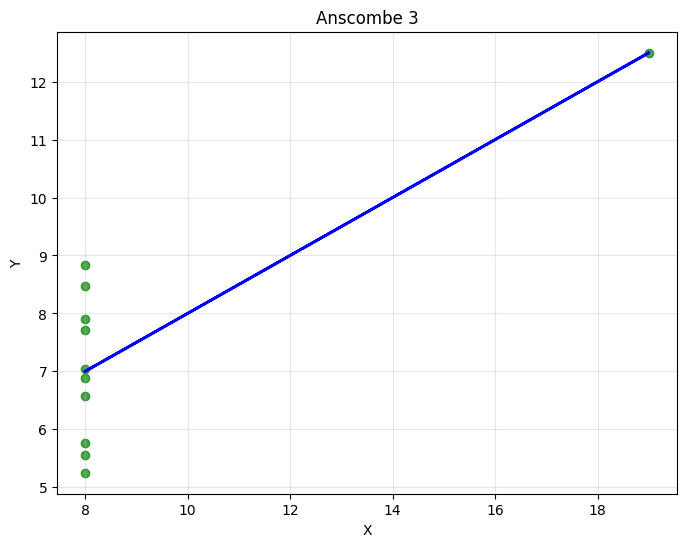

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
fit_and_plot_anscombe(quartet_df['x4'], quartet_df['y4'], "Anscombe 3")

Как видно, все эти зависимости имеют разную природу, но при этом порождают модели с практически одинаковыми параметрами. Таким образом, чрезвычайно важно проводить достаточно объемный EDA.
Датасте же - известный набор [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet)

# Положения линейной регрессии
Далее рассмотрим некоторые положения линейной регрессии, которые задают границы ее применимости (а также что бывает, когда они нарушаются).

**Линейность**: взаимосвязь между зависимыми и независимыми переменными линейна.

**Независимость**: Наблюдения независимы друг от друга.

**Гомоскедастичность**: дисперсия ошибок постоянна на всех уровнях независимых переменных.

**Нормальность**: ошибки подчиняются нормальному распределению.

**Нет мультиколлинеарности**: независимые переменные не сильно коррелируют друг с другом.

**Нет эндогенности**: между ошибками и независимыми переменными нет связи.

## Нелинейность

Рассмотрим набор данных Bluegills.
В 1981 году n = 78 [cинежаберных солнечников](https://ru.wikipedia.org/wiki/%D0%A1%D0%B8%D0%BD%D0%B5%D0%B6%D0%B0%D0%B1%D0%B5%D1%80%D0%BD%D1%8B%D0%B9_%D1%81%D0%BE%D0%BB%D0%BD%D0%B5%D1%87%D0%BD%D0%B8%D0%BA) были случайным образом отобраны из озера Мэри в Миннесоте (Кук и Вайсберг, 1999):
* Длина (в мм) рыбы
* Возраст (в годах) рыбы


In [99]:
df = pd.read_csv(f"{data_path}/bluegills.txt", sep="\t")

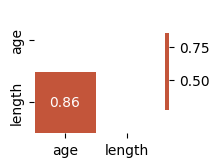

In [100]:
corrplot(df)

<Axes: xlabel='age', ylabel='length'>

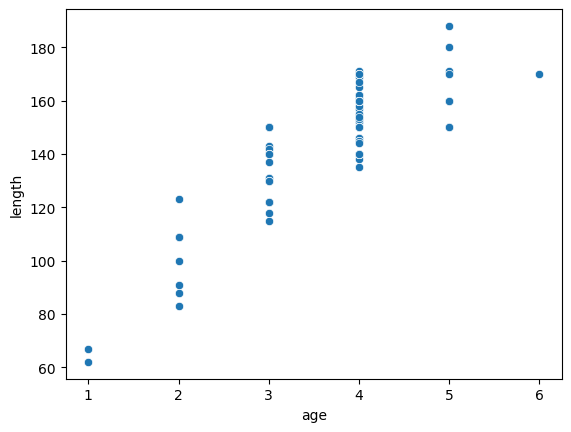

In [101]:
sns.scatterplot(df, x="age", y="length")

График позволяет предположить, что в данных наблюдается положительная динамика. Неудивительно, что с увеличением возраста рыб их длина имеет тенденцию к увеличению. Однако эта тенденция не выглядит вполне линейной. Кажется, что отношения слегка искривлены.

Один из способов моделирования кривизны этих данных — сформулировать «полиномиальную модель второго порядка»:

$ Y=\beta_0+ \sum_i (\alpha_i  X_i^2) + \sum_i (\beta_i  X_i) + \sum_{j \neq i} (\gamma_{ij}  X_i X_j) + \epsilon $

Сделать это просто, введя в данные полиномиальные признаки (PolynomialFeatures) и обучив обычную линейную модель.

In [102]:
X = np.array(df["age"]).reshape(-1, 1)
y =np.array(df["length"])
model_basic = LinearRegression()
model_basic.fit(X, df["length"])
y_basic = model_basic.predict(X)

In [103]:
degree = 2  # Set the polynomial degree
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X=np.array(df.loc[:,"age"]).reshape(-1, 1))
X = np.array(df["age"]).reshape(-1, 1)
y = np.array(df["length"])
model_basic = LinearRegression()
model_basic.fit(X, df["length"])
model_poly = LinearRegression()
model_poly.fit(X_poly,  df["length"])
y_basic = model_basic.predict(X)
y_poly = model_poly.predict(X_poly)

In [104]:
print(f"coefficient of determination of linear model: {model_basic.score(X, y)}")
print(f"coefficient of determination of polynomial model: {model_poly.score(X_poly, y)}")

coefficient of determination of linear model: 0.7348821471782518
coefficient of determination of polynomial model: 0.8011378030846004


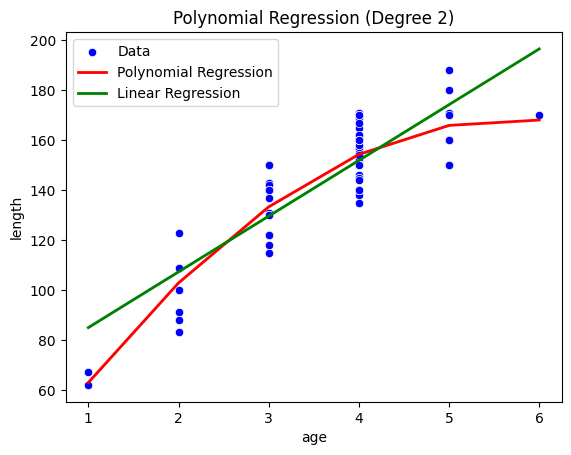

In [105]:
sns.scatterplot(df,x="age", y="length", label='Data', color='blue')
sns.lineplot(x=df["age"], y=y_poly, label='Polynomial Regression', color='red', linewidth=2)
sns.lineplot(x=df["age"], y=y_basic, label='Linear Regression', color='green', linewidth=2)
plt.xlabel('age')
plt.ylabel('length')
plt.legend()
plt.title(f'Polynomial Regression (Degree {degree})')
plt.show()

In [106]:
degree = 3  # Set the polynomial degree
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X=np.array(df.loc[:,"age"]).reshape(-1, 1))
X = np.array(df["age"]).reshape(-1, 1)
y =np.array(df["length"])
model_basic = LinearRegression()
model_basic.fit(X, df["length"])
model_poly = LinearRegression()
model_poly.fit(X_poly,  df["length"])
y_basic = model_basic.predict(X)
y_poly = model_poly.predict(X_poly)

In [107]:
print(f"coefficient of determination of linear model: {model_basic.score(X, y)}")
print(f"coefficient of determination of polynomial model: {model_poly.score(X_poly, y)}")

coefficient of determination of linear model: 0.7348821471782518
coefficient of determination of polynomial model: 0.8012490266329881


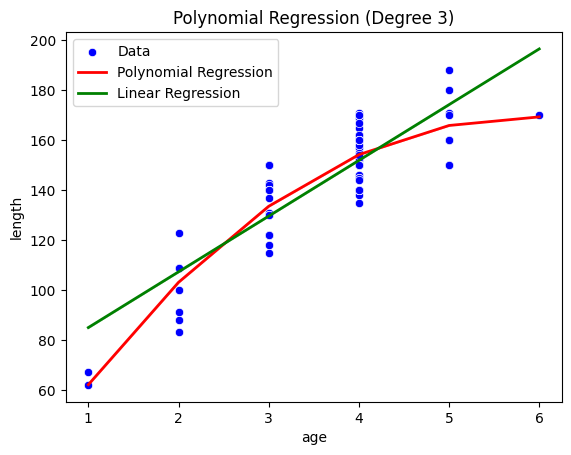

In [108]:
sns.scatterplot(df,x="age", y="length", label='Data', color='blue')
sns.lineplot(x=df["age"], y=y_poly, label='Polynomial Regression', color='red', linewidth=2)
sns.lineplot(x=df["age"], y=y_basic, label='Linear Regression', color='green', linewidth=2)
plt.xlabel('age')
plt.ylabel('length')
plt.legend()
plt.title(f'Polynomial Regression (Degree {degree})')
plt.show()

**Задание**: Постройте модель для наборов Anscombe 1 и Anscombe 2. Напишите, какие степени полинома подойдут лучше всего.

 Anscombe Dataset 1 (линейная с шумом)


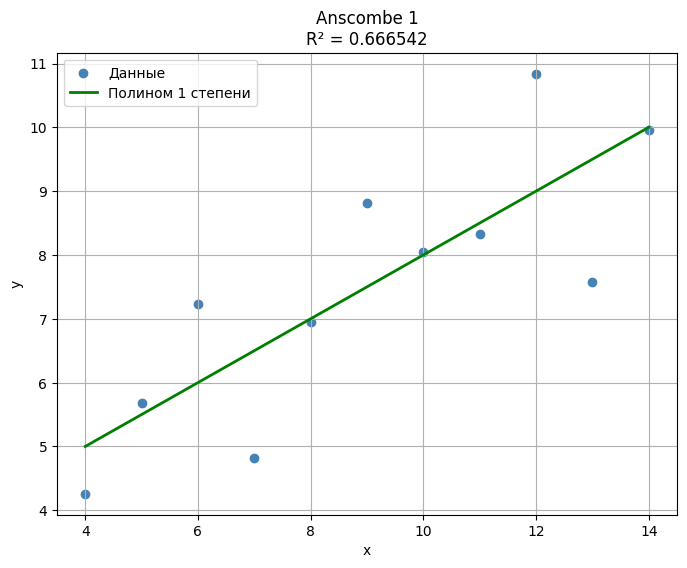

Anscombe 1 — степень 1: R² = 0.666542


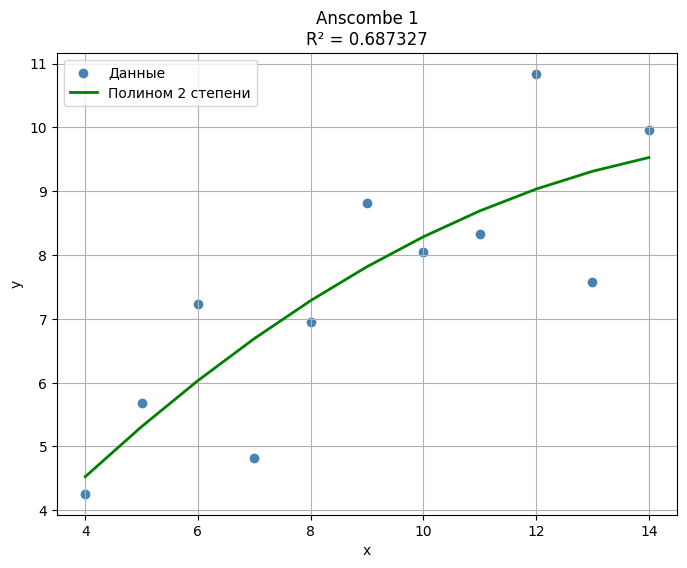

Anscombe 1 — степень 2: R² = 0.687327


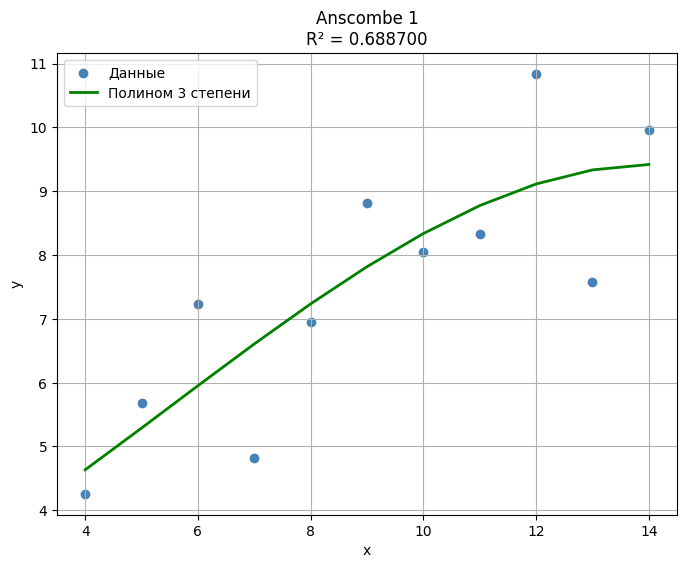

Anscombe 1 — степень 3: R² = 0.688700


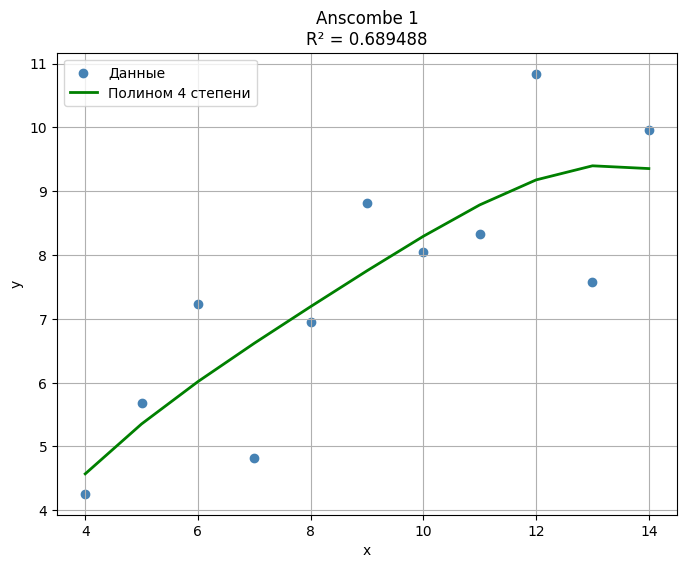

Anscombe 1 — степень 4: R² = 0.689488


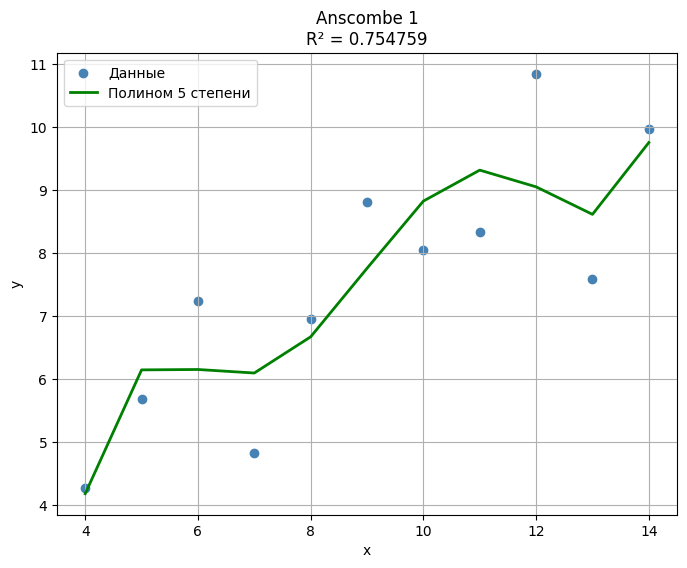

Anscombe 1 — степень 5: R² = 0.754759

 Anscombe Dataset 2 (квадратичная зависимость)


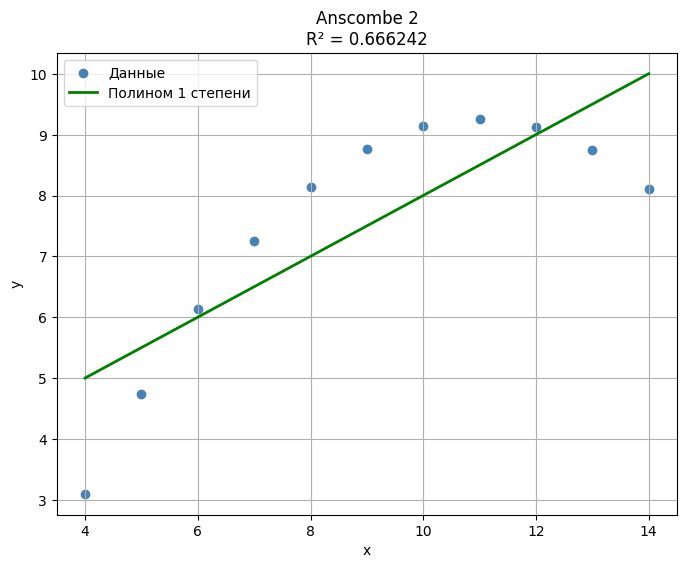

Anscombe 2 — степень 1: R² = 0.666242


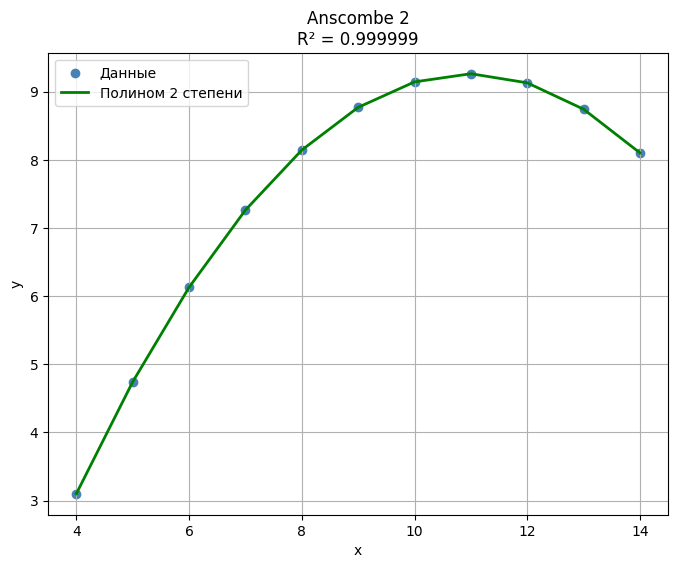

Anscombe 2 — степень 2: R² = 0.999999


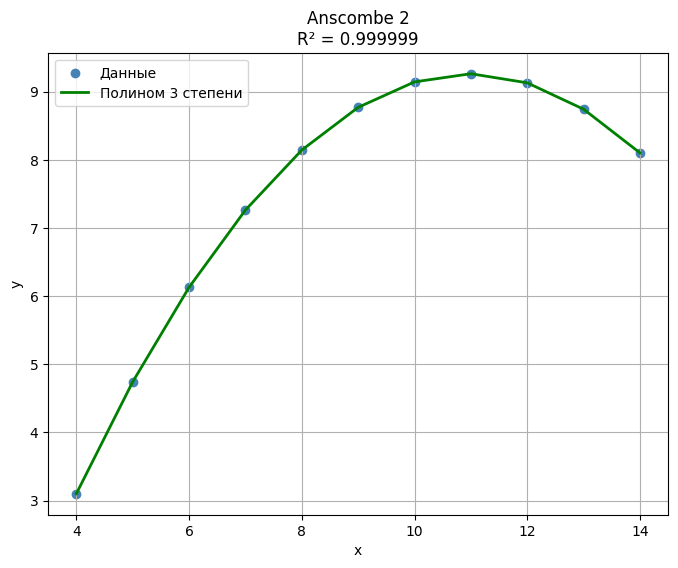

Anscombe 2 — степень 3: R² = 0.999999


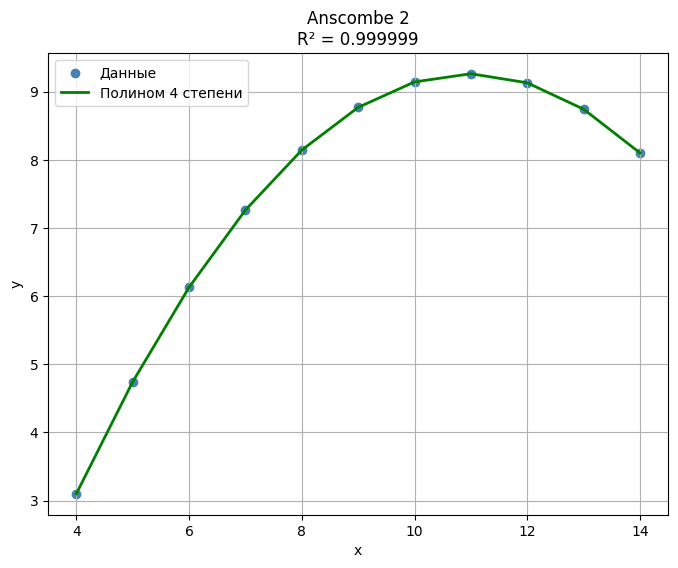

Anscombe 2 — степень 4: R² = 0.999999


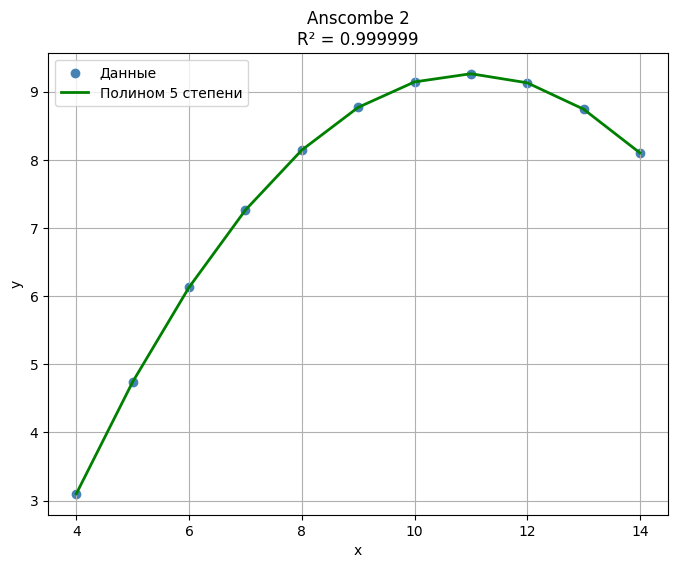

Anscombe 2 — степень 5: R² = 0.999999


In [109]:
from sklearn.metrics import r2_score

df = pd.read_csv(f'{data_path}/Anscombe_quartet_data.csv')

# Датасет 1: x123 -> y1
X1 = df[['x123']].values
y1 = df['y1'].values

# Датасет 2: x123 -> y2
X2 = df[['x123']].values
y2 = df['y2'].values

def fit_polynomial(X, y, degree, title):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    X_sorted = np.sort(X, axis=0)
    y_pred_line = model.predict(X_sorted)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='steelblue', label='Данные')
    plt.plot(X_sorted, y_pred_line, color='green', linewidth=2, 
             label=f'Полином {degree} степени')
    plt.title(f'{title}\nR² = {r2:.6f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"{title} — степень {degree}: R² = {r2:.6f}")

print(" Anscombe Dataset 1 (линейная с шумом)")
for deg in range(1, 6):
    fit_polynomial(X1, y1, deg, "Anscombe 1")

print("\n Anscombe Dataset 2 (квадратичная зависимость)")
for deg in range(1, 6):
    fit_polynomial(X2, y2, deg, "Anscombe 2")


**Выводы по результатам:**

 **Anscombe 1**: лучшая степень — **1** (R² ≈ 0.6665). Более высокие степени лишь незначительно повышают R² за счёт переобучения.
 
 **Anscombe 2**: лучшая степень — **2** (R² ≈ 1.0000). Полином 2 степени идеально описывает параболу. Выше — избыточно.

**Задание со звездочкой**: Постройте модель с использованием другого базиса, не полиномиального. Проиллюстрируйте ее применение на примерах из практики.

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\maksc\AppData\Local\Temp\ipykernel_3480\2169765857.py:5: SyntaxWarning: invalid escape sequence '\s'
  bluegills = pd.read_csv(f'{data_path}/bluegills.txt', sep='\s+')


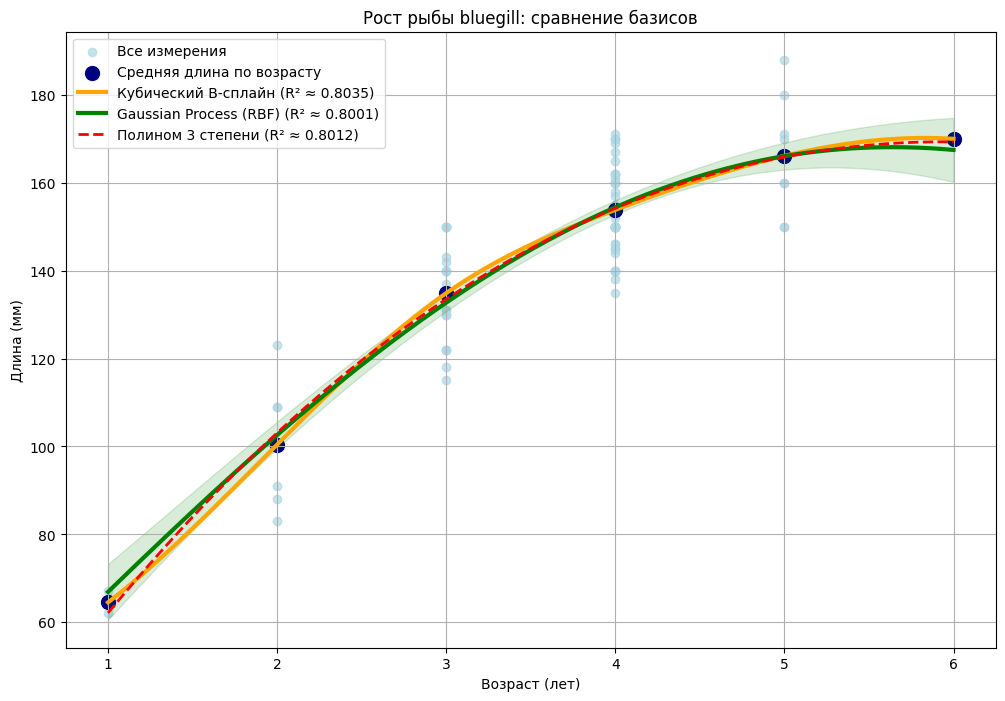

Полином 3 степени R²: 0.8012
Сплайн R²: 0.8035
Gaussian Process (RBF) R²: 0.8001


In [110]:
from scipy.interpolate import make_interp_spline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

bluegills = pd.read_csv(f'{data_path}/bluegills.txt', sep='\s+')

X_all = bluegills[['age']].values
y_all = bluegills['length'].values

means = bluegills.groupby('age')['length'].mean()
x_mean = means.index.values
y_mean = means.values
x_smooth = np.linspace(x_mean.min(), x_mean.max(), 300)

# 0. Полином 3 степени для сравнения
poly = np.poly1d(np.polyfit(bluegills['age'], bluegills['length'], 3))
y_poly = poly(x_smooth)
r2_poly = r2_score(y_all, poly(bluegills['age']))

# 1. Gaussian Process с RBF базисом (неполиномиальный)
kernel = C(1.0) * RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=150.0)
gp.fit(X_all, y_all)
y_gp, sigma = gp.predict(x_smooth.reshape(-1, 1), return_std=True)
y_gp_train = gp.predict(X_all)
r2_gp = r2_score(y_all, y_gp_train)

# 2. Кубический сплайн (B-spline)
spl = make_interp_spline(sorted(x_mean), y_mean[np.argsort(x_mean)], k=3)
y_spl = spl(x_smooth)
y_pred_spl = spl(bluegills['age'].values)
r2_spl = r2_score(y_all, y_pred_spl)


plt.figure(figsize=(12, 8))
plt.scatter(bluegills['age'], bluegills['length'], color='lightblue', alpha=0.7, label='Все измерения')
plt.scatter(x_mean, y_mean, color='navy', s=100, label='Средняя длина по возрасту')
plt.plot(x_smooth, y_spl, color='orange', linewidth=3, label=f'Кубический B-сплайн (R² ≈ {r2_spl:.4f})')
plt.plot(x_smooth, y_gp, color='green', linewidth=3, label=f'Gaussian Process (RBF) (R² ≈ {r2_gp:.4f})')
plt.plot(x_smooth, y_poly, color='red', linestyle='--', linewidth=2, label=f'Полином 3 степени (R² ≈ {r2_poly:.4f})')
plt.fill_between(x_smooth, y_gp - sigma, y_gp + sigma, color='green', alpha=0.15)
plt.title('Рост рыбы bluegill: сравнение базисов')
plt.xlabel('Возраст (лет)')
plt.ylabel('Длина (мм)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Полином 3 степени R²: {r2_poly:.4f}")
print(f"Сплайн R²: {r2_spl:.4f}")
print(f"Gaussian Process (RBF) R²: {r2_gp:.4f}")

## Выбросы
Как мы уже видели, выбросы могут сильно влиять на предсказания линейной модели. Даже один выброс может нарушить одно из условий линейной регрессии. К счастью, существует много сапособов с ними бороться.
Простейший вариант - использовать не MSE, а MAE. Почему?
Однако есть и более сложные варианты. Например, комбинация MSE и MAE дает **HuberLoss**:

$$L_\delta(r) = \begin{cases}
\frac{1}{2}r^2 & \text{если } |r| \leq \delta \\
\delta|r| - \frac{1}{2}\delta^2 & \text{если } |r| > \delta
\end{cases}$$

где $r = y_i - \mathbf{x}_i^T \beta$ — остаток, $\delta$ — параметр переключения.

- При малых ошибках ($|r| \leq \delta$) ведет себя как OLS
- При больших ошибках ($|r| > \delta$) ведет себя как MAE 


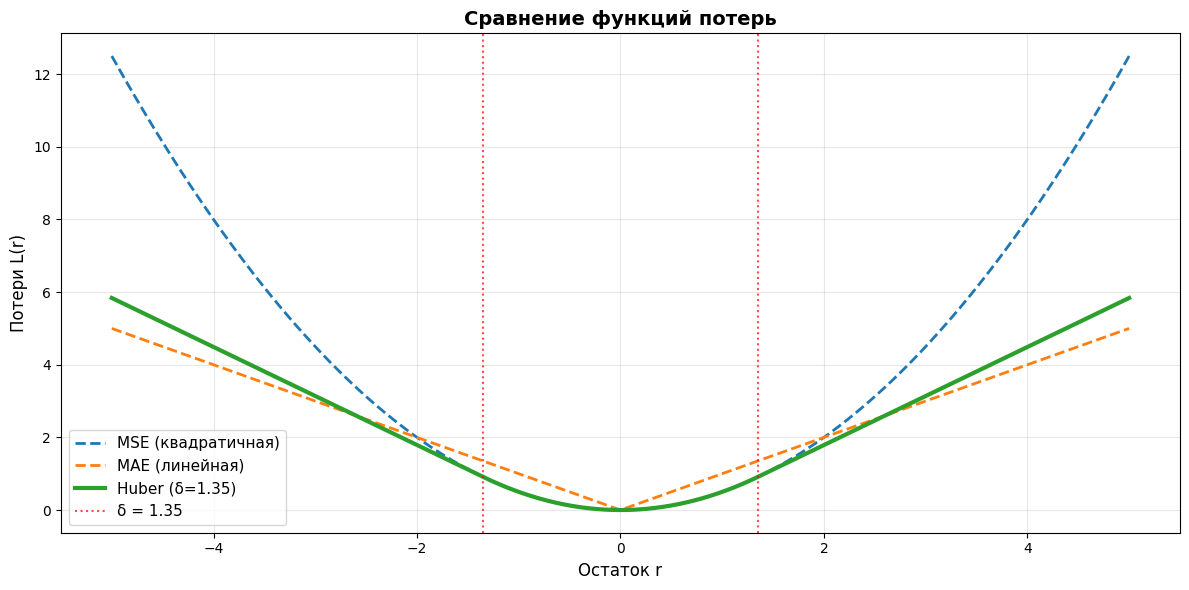

In [111]:
# Визуализация функции потерь Huber
def huber_loss(r, delta):
    """Вычисляет функцию потерь Huber."""
    return np.where(np.abs(r) <= delta, 0.5 * r**2, delta * np.abs(r) - 0.5 * delta**2)

r = np.linspace(-5, 5, 1000)
delta = 1.35

mse_loss = 0.5 * r**2
mae_loss = np.abs(r)
huber = huber_loss(r, delta)

plt.figure(figsize=(12, 6))
plt.plot(r, mse_loss, label='MSE (квадратичная)', linewidth=2, linestyle='--')
plt.plot(r, mae_loss, label='MAE (линейная)', linewidth=2, linestyle='--')
plt.plot(r, huber, label=f'Huber (δ={delta})', linewidth=3)
plt.axvline(x=delta, color='red', linestyle=':', alpha=0.7, label=f'δ = {delta}')
plt.axvline(x=-delta, color='red', linestyle=':', alpha=0.7)
plt.xlabel('Остаток r', fontsize=12)
plt.ylabel('Потери L(r)', fontsize=12)
plt.title('Сравнение функций потерь', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


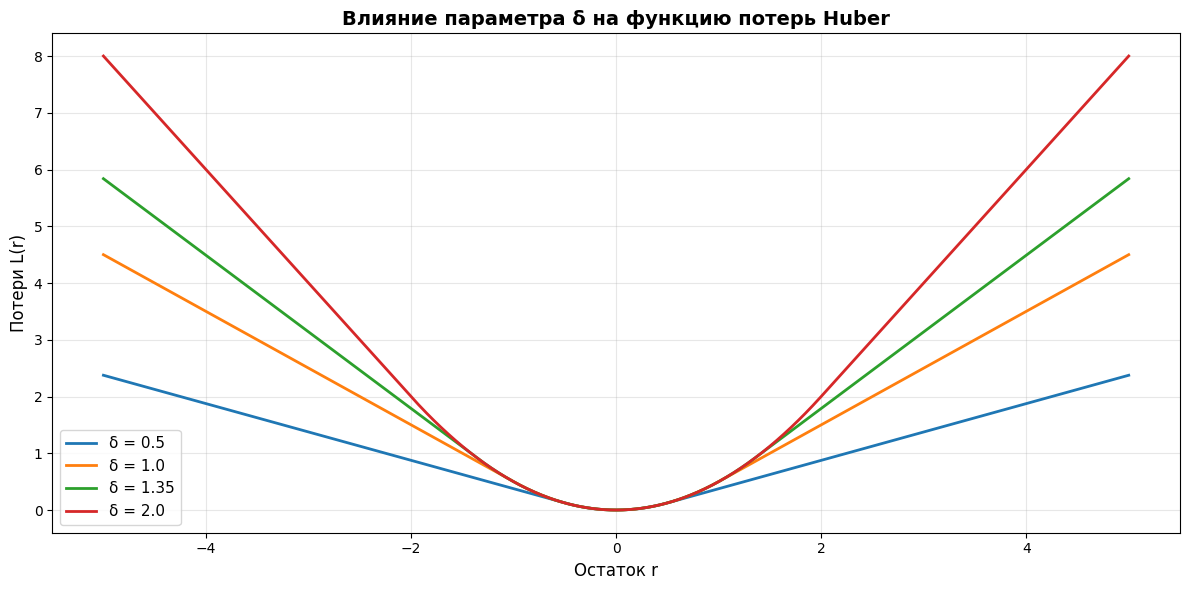

In [112]:
# Влияние параметра delta на функцию потерь
deltas = [0.5, 1.0, 1.35, 2.0]
r = np.linspace(-5, 5, 1000)

plt.figure(figsize=(12, 6))
for delta in deltas:
    huber = huber_loss(r, delta)
    plt.plot(r, huber, label=f'δ = {delta}', linewidth=2)

plt.xlabel('Остаток r', fontsize=12)
plt.ylabel('Потери L(r)', fontsize=12)
plt.title('Влияние параметра δ на функцию потерь Huber', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Другой робастный вариант - **Theil-Sen regression**. Этот метод строит медиану наклона модели между всеми парами наблюдений. Метод непараметрический. Проблема этого метода в том, что для больших наборов данных вычислительная сложность метода становится слишком большой ($O(n^2)$ для наклона, $O(n \log n)$ для медианы):

**Алгоритм**:
1. Для всех пар точек $(x_i, y_i)$ и $(x_j, y_j)$, где $i < j$, вычисляется наклон:
   $$b_{ij} = \frac{y_j - y_i}{x_j - x_i}$$
2. Оценка наклона: $\hat{\beta}_1 = \text{median}(\{b_{ij}\})$
3. Оценка свободного члена: $\hat{\beta}_0 = \text{median}(\{y_i - \hat{\beta}_1 x_i\})$

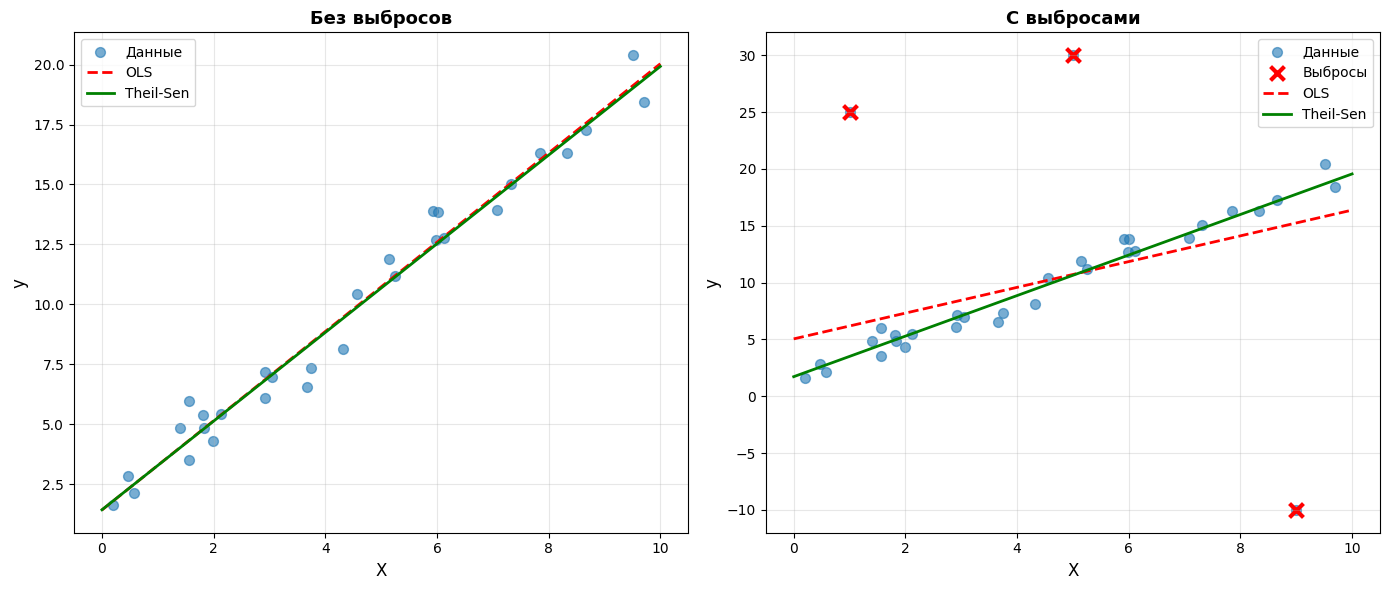

In [113]:
# Иллюстрация работы Theil-Sen
np.random.seed(42)
n = 30
X_clean = np.random.uniform(0, 10, n)
y_clean = 2 * X_clean + 1 + np.random.normal(0, 1, n)

# Добавляем выбросы
X_outliers = np.append(X_clean, [1, 9, 5])
y_outliers = np.append(y_clean, [25, -10, 30])

# OLS
ols = LinearRegression()
ols.fit(X_clean.reshape(-1, 1), y_clean)
ols_outliers = LinearRegression()
ols_outliers.fit(X_outliers.reshape(-1, 1), y_outliers)

# Theil-Sen
theil = TheilSenRegressor(random_state=42)
theil.fit(X_clean.reshape(-1, 1), y_clean)
theil_outliers = TheilSenRegressor(random_state=42)
theil_outliers.fit(X_outliers.reshape(-1, 1), y_outliers)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Без выбросов
axes[0].scatter(X_clean, y_clean, alpha=0.6, s=50, label='Данные')
x_plot = np.linspace(0, 10, 100)
axes[0].plot(x_plot, ols.predict(x_plot.reshape(-1, 1)), 'r--', linewidth=2, label='OLS')
axes[0].plot(x_plot, theil.predict(x_plot.reshape(-1, 1)), 'g-', linewidth=2, label='Theil-Sen')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Без выбросов', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# С выбросами
axes[1].scatter(X_outliers, y_outliers, alpha=0.6, s=50, label='Данные')
axes[1].scatter([1, 9, 5], [25, -10, 30], color='red', s=100, marker='x', linewidths=3, label='Выбросы')
axes[1].plot(x_plot, ols_outliers.predict(x_plot.reshape(-1, 1)), 'r--', linewidth=2, label='OLS')
axes[1].plot(x_plot, theil_outliers.predict(x_plot.reshape(-1, 1)), 'g-', linewidth=2, label='Theil-Sen')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('С выбросами', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Третий метод: **RANSAC**. Его идея в том, чтобы сначала построить много моделей-кандидатов, а потом выбрать из них лучшую.

**Алгоритм**:
1. Случайно выбирается минимальная подвыборка для оценки параметров (для линейной регрессии — 2 точки)
2. На подвыборке строится модель
3. Вычисляются остатки для всех точек. Точки с остатками меньше порога $t$ считаются inliers (внутренними)
4. Если количество inliers достаточно велико, модель переоценивается на всех inliers
5. Шаги 1-4 повторяются $N$ раз
6. Выбирается модель с наибольшим количеством inliers

Вероятность того, что на всех итерациях до $N$ хотя бы 1 точка будет выбросом (то есть построится некорректная модель) $(1-q)^N$, где q - доля выбросов. Таким образом, мы можем примерно оценить, сколько нам потребуется итераций, а метод становится наиболее толерантным к числу выбросов. Минус в том, что верхняя граница числа итераций фактически не задана, а наша оценка может быть недостаточной.

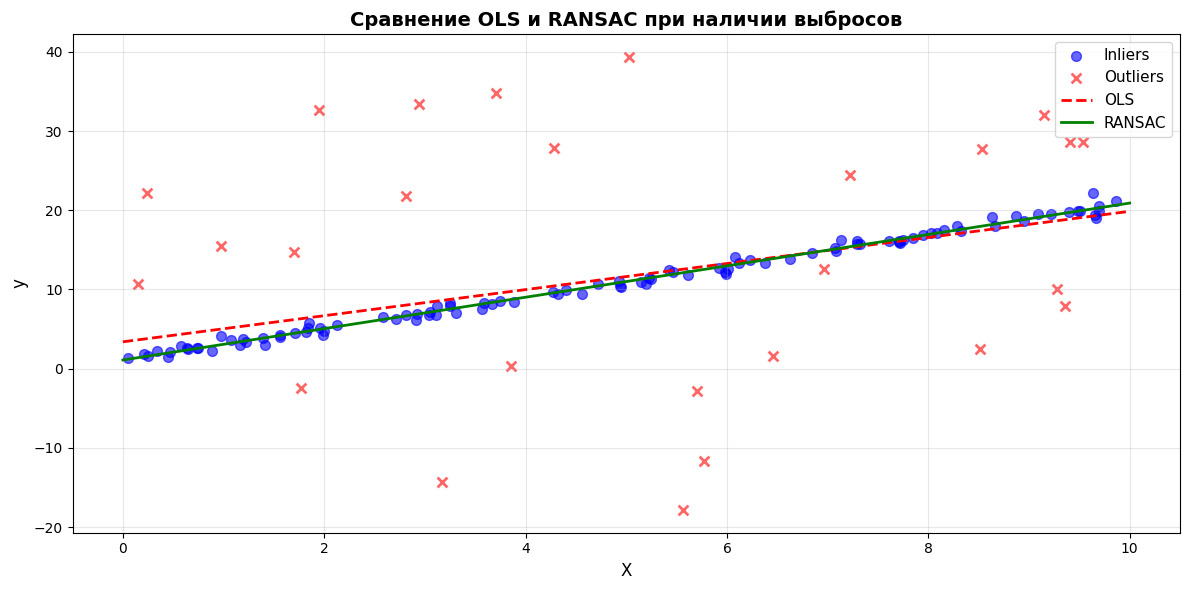

Количество inliers: 104
Количество outliers: 26


In [114]:
# Иллюстрация работы RANSAC
np.random.seed(42)
n = 100
X = np.random.uniform(0, 10, n)
y = 2 * X + 1 + np.random.normal(0, 0.5, n)

# Добавляем выбросы
n_outliers = 30
X_outliers = np.append(X, np.random.uniform(0, 10, n_outliers))
y_outliers = np.append(y, np.random.uniform(-20, 40, n_outliers))

# Модели
ols = LinearRegression()
ols.fit(X_outliers.reshape(-1, 1), y_outliers)

ransac = RANSACRegressor(random_state=42, residual_threshold=2.0, max_trials=100)
ransac.fit(X_outliers.reshape(-1, 1), y_outliers)

# Разделение на inliers и outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Визуализация
plt.figure(figsize=(12, 6))
x_plot = np.linspace(0, 10, 100)

plt.scatter(X_outliers[inlier_mask], y_outliers[inlier_mask], 
           color='blue', alpha=0.6, s=50, label='Inliers')
plt.scatter(X_outliers[outlier_mask], y_outliers[outlier_mask], 
           color='red', alpha=0.6, s=50, marker='x', linewidths=2, label='Outliers')
plt.plot(x_plot, ols.predict(x_plot.reshape(-1, 1)), 'r--', linewidth=2, label='OLS')
plt.plot(x_plot, ransac.predict(x_plot.reshape(-1, 1)), 'g-', linewidth=2, label='RANSAC')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Сравнение OLS и RANSAC при наличии выбросов', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Количество inliers: {np.sum(inlier_mask)}")
print(f"Количество outliers: {np.sum(outlier_mask)}")



Почему мы захотим применять тот или иной метод, зависит от наших требований (на скорость обучения, например) и толерантности к выбросам, которую мы можем себе позволить.

**Breakdown point** (точка разрушения) — минимальная доля выбросов, которая может сделать оценку сколь угодно плохой (то есть изменение параметров перестает быть ограниченным при добавлении следующих выбросов).

- OLS: breakdown point = 0% (один выброс может разрушить оценку)
- Медианная регрессия: breakdown point = 50%
- Theil-Sen: breakdown point ≈ 29.3%
- RANSAC: зависит от параметров, обычно 30-50%
- Huber: breakdown point зависит от параметра $\epsilon$, обычно 10-20%


Рассмотрим синтетические данные. Пусть это будут синусоидальные данные, но некоторые наблюдения будут "испорчены"

In [115]:
X = np.random.uniform(0, 1.5, size=300)
y = np.sin(1.5 * np.pi * X) + np.random.normal(scale=0.1, size=X.shape)
X = X.reshape(-1,1)

X_test = np.random.uniform(0, 1.5, size=300) 
y_test = np.sin(1.5 * np.pi * X_test) + np.random.normal(scale=0.1, size=X_test.shape)
X_test = X_test.reshape(-1,1)

y_errors = y.copy()
y_errors[::5] = 3

X_errors = X.copy()
X_errors[::5] = 3

y_errors_large = y.copy()
y_errors_large[::5] = 10

X_errors_large = X.copy()
X_errors_large[::5] = 10

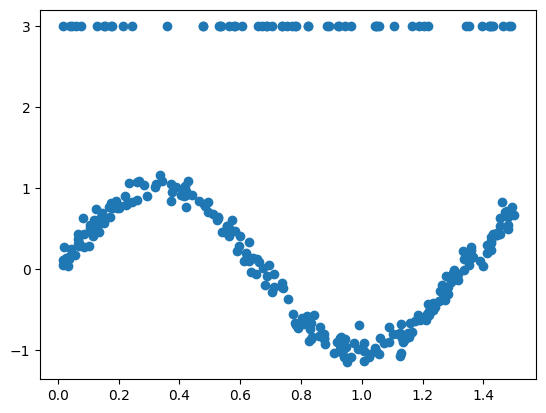

In [116]:
plt.scatter(X, y_errors)

Задание: Последовательно постройте различные модели для разных видов испорченности данных.

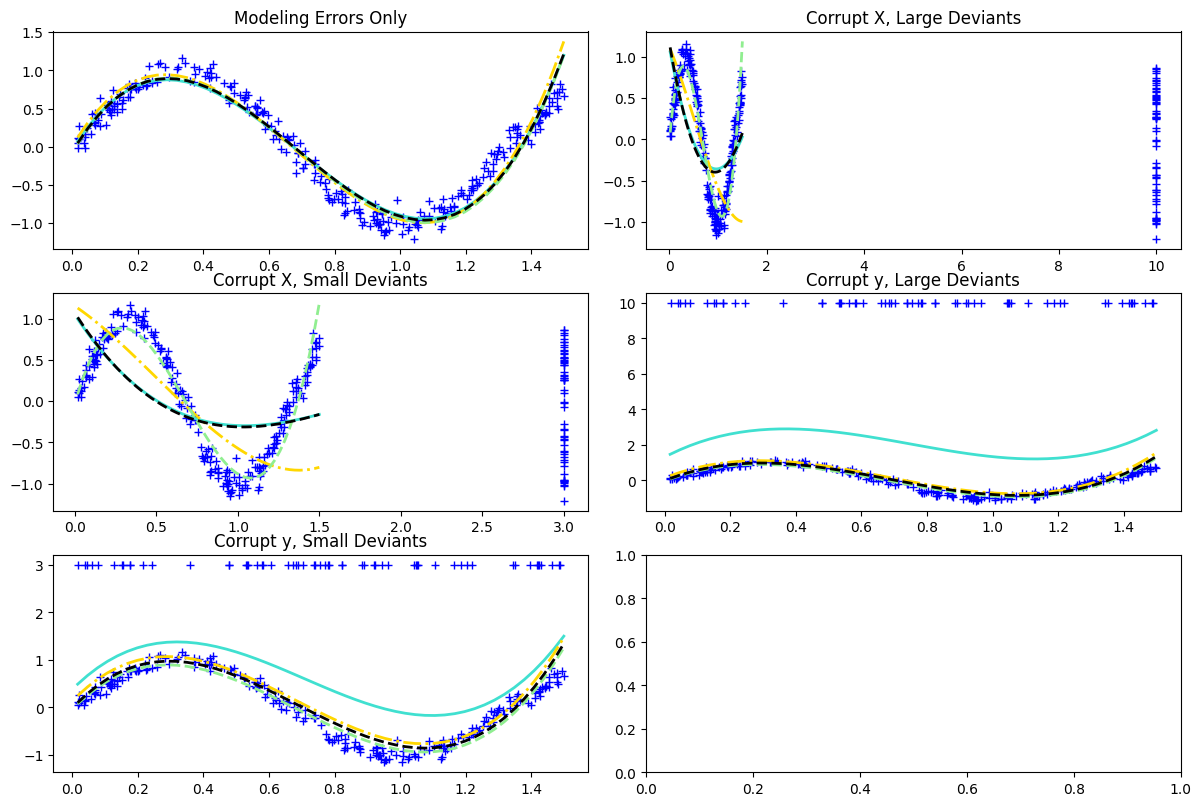

In [117]:
estimators = {
    "OLS": LinearRegression(),
    "Theil-Sen": TheilSenRegressor(random_state=42),
    "RANSAC": RANSACRegressor(random_state=42),
    "Huber": HuberRegressor(),
}

colors = {
    "OLS": "turquoise",
    "Theil-Sen": "gold",
    "RANSAC": "lightgreen",
    "Huber": "black",
}
linestyle = {"OLS": "-", "Theil-Sen": "-.", "RANSAC": "--", "Huber": "--"}
lw = 2
fig, ax = plt.subplots(nrows=3, ncols=2, figsize= (12,8))
fig.tight_layout()
x_plot = np.linspace(X.min(), X.max())
time_dict = {name: 0. for name in estimators.keys()}
errors_df = pd.DataFrame(columns = list(estimators.keys()))
time_dict["Problem"] = "Sum time"
for i, (title, this_X, this_y) in enumerate([
    ("Modeling Errors Only", X, y),
    ("Corrupt X, Small Deviants", X_errors, y),
    ("Corrupt y, Small Deviants", X, y_errors),
    ("Corrupt X, Large Deviants", X_errors_large, y),
    ("Corrupt y, Large Deviants", X, y_errors_large),
]):
    ax[i % 3, i // 3].plot(this_X[:, 0], this_y, "b+")
    errors_dict = {"Problem": title}
    for name, estimator in estimators.items():
        model = make_pipeline(PolynomialFeatures(3), estimator)
        t0 = time.time()
        model.fit(this_X, this_y)
        time_dict[name] += time.time() - t0
        mse = mean_squared_error(model.predict(X_test), y_test)
        errors_dict[name] = [mse]
        y_plot = model.predict(x_plot[:, np.newaxis])
        ax[i % 3, i // 3].plot(
            x_plot,
            y_plot,
            color=colors[name],
            linestyle=linestyle[name],
            linewidth=lw,
            label="%s: error = %.3f" % (name, mse),
        )
    errors_df = pd.concat([errors_df,pd.DataFrame.from_dict(data=errors_dict)])
    ax[i % 3, i // 3].title.set_text(title)
errors_df = pd.concat([errors_df, pd.DataFrame(time_dict, index=[0])]) 
plt.show()

In [118]:
errors_df

,OLS,Theil-Sen,RANSAC,Huber,Problem
0,0.036775,0.037749,0.038612,0.036871,Modeling Errors Only
0,0.322312,0.38631,0.036502,0.321699,"Corrupt X, Small Deviants"
0,0.395312,0.061665,0.035835,0.039736,"Corrupt y, Small Deviants"
0,0.297509,0.447126,0.036502,0.297321,"Corrupt X, Large Deviants"
0,4.050281,0.070167,0.035835,0.039737,"Corrupt y, Large Deviants"
0,0.005009,1.415455,0.044064,0.048746,Sum time


**Задание**: Поиграйте с этими датасетами и параметрами моделей.  
Ответьте на вопросы:
- При каких размерах датасетов лучше использовать каждый из алгоритмов
- При каких процентах выбросов и их значениях лучше использовать каждый из алгоритмов
- Влияет ли то, как распределены выбросы, на выбор метода
- Влияет ли отношение шума к сигналу на выбор алгоритма
- Какие алгоритмы более чувствительны к параметрам, какие менее  
Для ответов покажите таблицы и/или графики

In [119]:
np.random.seed(42)

X_test = np.linspace(0, 1.5, 500).reshape(-1, 1)
y_test = np.sin(1.5 * np.pi * X_test[:, 0]) + np.random.normal(0, 0.1, X_test.shape[0])

estimators = {
    "OLS": LinearRegression(),
    "Huber": HuberRegressor(epsilon=1.35),
    "Theil-Sen": TheilSenRegressor(random_state=42, max_subpopulation=1000),
    "RANSAC": RANSACRegressor(random_state=42, residual_threshold=0.5, max_trials=100),
}

colors = ["turquoise", "gold", "lightgreen", "black"]

def generate_dataset(n=300, outlier_pct=0.2, outlier_mag=10.0, 
                  noise_level=0.1, clustered=False):
    X = np.random.uniform(0, 1.5, n).reshape(-1, 1)
    y = np.sin(1.5 * np.pi * X[:, 0]) + np.random.normal(0, noise_level, n)
    
    if outlier_pct > 0:
        n_out = int(n * outlier_pct)
        idx = np.random.choice(n, n_out, replace=False)
        
        # Выбросы в y (вертикальные)
        y_shifts = np.random.choice([-1, 1], n_out) * outlier_mag
        y[idx] += y_shifts
        
        # Выбросы в X (горизонтальные) 
        x_shifts = np.random.choice([-1, 1], n_out) * (outlier_mag / 5)
        X[idx] += x_shifts.reshape(-1, 1)  
        
        if clustered:
            cluster_idx = idx[:n_out//2]
            X[cluster_idx] = np.random.uniform(0.9, 1.1, len(cluster_idx)).reshape(-1, 1)
    
    return X, y

 Эксперимент 1: Размер датасета 


,n,OLS_MSE,OLS_Time,Huber_MSE,Huber_Time,Theil-Sen_MSE,Theil-Sen_Time,RANSAC_MSE,RANSAC_Time
0,100,0.298298,0.000000,0.191868,0.016156,0.142114,0.034300,0.044540,0.009601
1,300,0.467619,0.000000,0.230966,0.014323,0.101974,0.025101,0.031862,0.000000
2,500,0.338397,0.000000,0.225558,0.000000,0.236858,0.034874,0.034230,0.015676
3,1000,0.337930,0.000000,0.225589,0.015618,0.201142,0.051777,0.033349,0.000000
4,2000,0.311874,0.015802,0.214004,0.000000,0.116308,0.067027,0.031676,0.026248


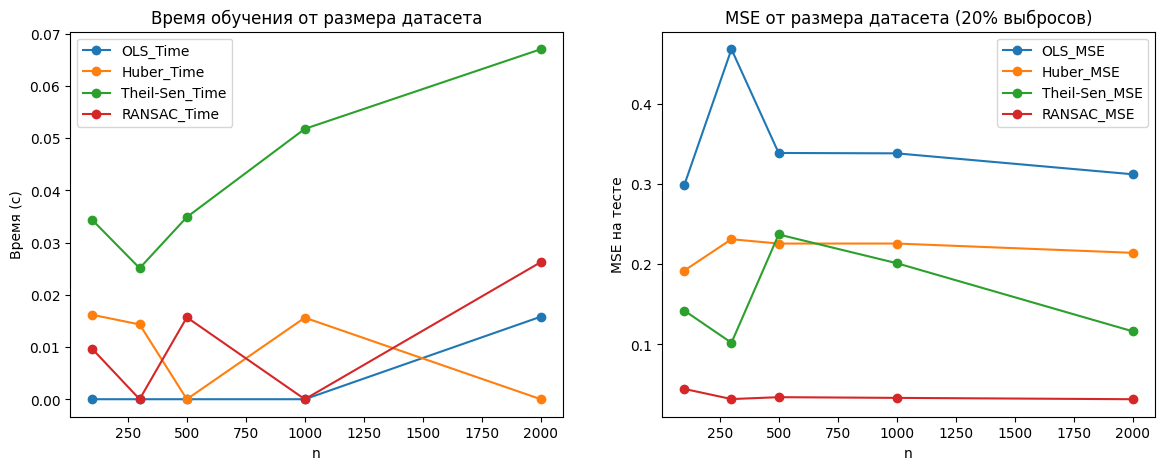

In [120]:
# 1. Эксперимент: размер датасета 
print(" Эксперимент 1: Размер датасета ")
sizes = [100, 300, 500, 1000, 2000]
results_size = []

for n in sizes:
    row = {"n": n}
    X, y = generate_dataset(n=n, outlier_pct=0.2, outlier_mag=5.0)
    for name, est in estimators.items():
        model = make_pipeline(PolynomialFeatures(3), est)
        t0 = time.time()
        model.fit(X, y)
        t = time.time() - t0
        mse = mean_squared_error(y_test, model.predict(X_test))
        row[name + "_MSE"] = mse
        row[name + "_Time"] = t
    results_size.append(row)

df_size = pd.DataFrame(results_size)
display(df_size)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_size.plot(x="n", y=[c + "_Time" for c in estimators.keys()], ax=ax[0], marker="o")
ax[0].set_title("Время обучения от размера датасета")
ax[0].set_ylabel("Время (с)")

df_size.plot(x="n", y=[c + "_MSE" for c in estimators.keys()], ax=ax[1], marker="o")
ax[1].set_title("MSE от размера датасета (20% выбросов)")
ax[1].set_ylabel("MSE на тесте")
plt.show()


 Эксперимент 2: Процент и магнитуда выбросов 


'Магнитуда = 3.0'

,outlier_pct,OLS,Huber,Theil-Sen,RANSAC
0,0.00,0.031811,0.032907,0.038650,0.032891
1,0.05,0.263795,0.055966,0.032685,0.070867
2,0.10,0.179293,0.060277,0.040581,0.121688
3,0.20,0.274573,0.165052,0.042055,0.040261
4,0.30,0.314404,0.140456,0.128225,0.040811
5,0.40,0.314150,0.210032,0.414683,0.032905


'Магнитуда = 10.0'

,outlier_pct,OLS,Huber,Theil-Sen,RANSAC
6,0.00,0.031616,0.032428,0.037600,0.031894
7,0.05,0.381715,0.262929,0.050217,0.042091
8,0.10,0.361231,0.338694,0.190116,0.050213
9,0.20,0.777063,0.264316,0.390214,0.031979
10,0.30,0.413429,0.437269,0.285159,0.121934
11,0.40,0.333248,0.411769,0.482115,0.033435


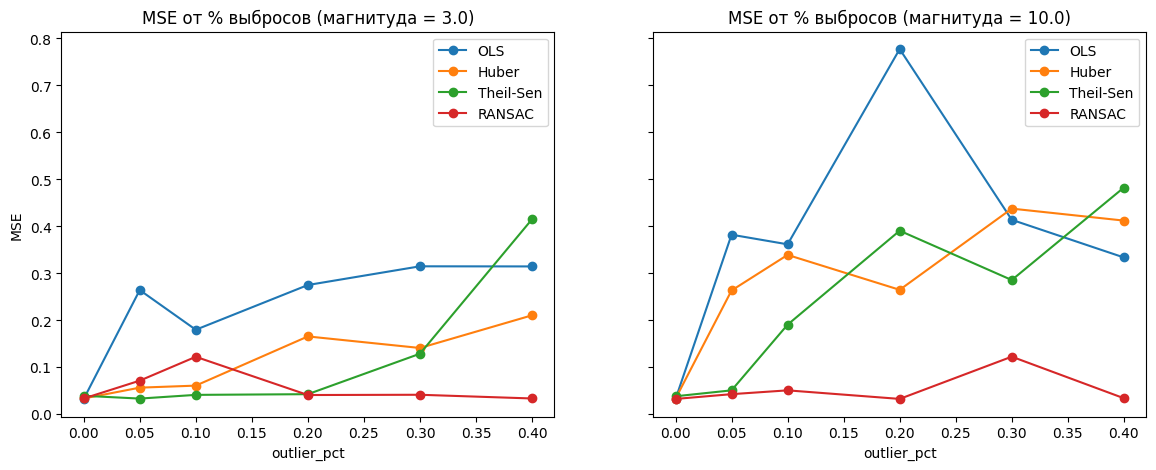

In [121]:
print("\n Эксперимент 2: Процент и магнитуда выбросов ")
pct_list = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
mag_list = [3.0, 10.0]
results_outlier = []

for mag in mag_list:
    for pct in pct_list:
        row = {"outlier_pct": pct, "outlier_mag": mag}
        X, y = generate_dataset(n=500, outlier_pct=pct, outlier_mag=mag)
        for name, est in estimators.items():
            model = make_pipeline(PolynomialFeatures(3), est)
            model.fit(X, y)
            mse = mean_squared_error(y_test, model.predict(X_test))
            row[name] = mse
        results_outlier.append(row)

df_outlier = pd.DataFrame(results_outlier)

display("Магнитуда = 3.0")
display(df_outlier[df_outlier["outlier_mag"] == 3.0].drop("outlier_mag", axis=1))
display("Магнитуда = 10.0")
display(df_outlier[df_outlier["outlier_mag"] == 10.0].drop("outlier_mag", axis=1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, mag in enumerate(mag_list):
    sub = df_outlier[df_outlier["outlier_mag"] == mag]
    sub.plot(x="outlier_pct", y=list(estimators.keys()), ax=ax[i], marker="o")
    ax[i].set_title(f"MSE от % выбросов (магнитуда = {mag})")
    ax[i].set_ylabel("MSE")
plt.show()

In [122]:
print("\n Эксперимент 3: Распределение выбросов ")
results_dist = []
for clustered in [False, True]:
    label = "clustered" if clustered else "uniform"
    X, y = generate_dataset(n=500, outlier_pct=0.25, outlier_mag=8.0, clustered=clustered)
    row = {"distribution": label}
    for name, est in estimators.items():
        model = make_pipeline(PolynomialFeatures(3), est)
        model.fit(X, y)
        mse = mean_squared_error(y_test, model.predict(X_test))
        row[name] = mse
    results_dist.append(row)

df_dist = pd.DataFrame(results_dist)
display(df_dist)


 Эксперимент 3: Распределение выбросов 


,distribution,OLS,Huber,Theil-Sen,RANSAC
0,uniform,0.404596,0.275582,0.359057,0.031595
1,clustered,0.312257,0.280696,0.339775,0.033775



 Эксперимент 4: Уровень шума 


,noise,OLS,Huber,Theil-Sen,RANSAC
0,0.05,0.512206,0.240713,0.141327,0.059495
1,0.10,0.343166,0.235128,0.241458,0.047532
2,0.20,0.331255,0.214102,0.159715,0.032577
3,0.40,0.286598,0.200784,0.176756,0.197443
4,0.60,0.444867,0.252603,0.230687,0.093451


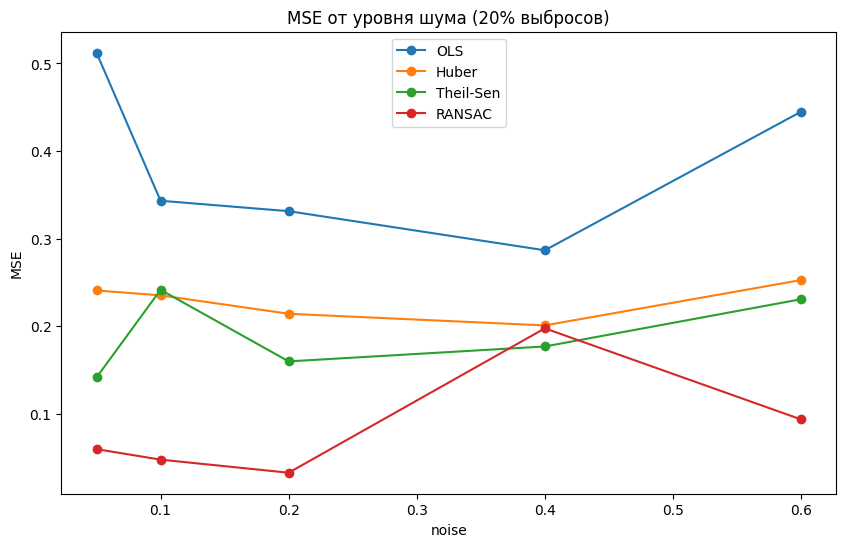

In [123]:
print("\n Эксперимент 4: Уровень шума ")
noise_levels = [0.05, 0.1, 0.2, 0.4, 0.6]
results_noise = []

for noise in noise_levels:
    row = {"noise": noise}
    X, y = generate_dataset(n=500, outlier_pct=0.2, outlier_mag=5.0, noise_level=noise)
    for name, est in estimators.items():
        model = make_pipeline(PolynomialFeatures(3), est)
        model.fit(X, y)
        mse = mean_squared_error(y_test, model.predict(X_test))
        row[name] = mse
    results_noise.append(row)

df_noise = pd.DataFrame(results_noise)
display(df_noise)

df_noise.plot(x="noise", y=list(estimators.keys()), marker="o", figsize=(10, 6), title="MSE от уровня шума (20% выбросов)")
plt.ylabel("MSE")
plt.show()

In [124]:
print("\n Эксперимент 5: Чувствительность к параметрам ")
X_fixed, y_fixed = generate_dataset(n=500, outlier_pct=0.25, outlier_mag=8.0)

# Huber — меняем epsilon
huber_mse = []
for eps in [1.0, 1.35, 1.5, 2.0, 3.0]:
    model = make_pipeline(PolynomialFeatures(3), HuberRegressor(epsilon=eps))
    model.fit(X_fixed, y_fixed)
    mse = mean_squared_error(y_test, model.predict(X_test))
    huber_mse.append(mse)
print("Huber epsilon варьирование MSE:", huber_mse, "std =", np.std(huber_mse))

# RANSAC — меняем residual_threshold
ransac_mse = []
for thr in [0.2, 0.5, 1.0, 2.0, 3.0]:
    model = make_pipeline(PolynomialFeatures(3), 
                          RANSACRegressor(random_state=42, residual_threshold=thr, max_trials=100))
    model.fit(X_fixed, y_fixed)
    mse = mean_squared_error(y_test, model.predict(X_test))
    ransac_mse.append(mse)
print("RANSAC threshold варьирование MSE:", ransac_mse, "std =", np.std(ransac_mse))


 Эксперимент 5: Чувствительность к параметрам 
Huber epsilon варьирование MSE: [0.31926901722251866, 0.321105116405922, 0.3480709345440733, 0.49548504955725925, 0.32883311037806134] std = 0.06724451084566045
RANSAC threshold варьирование MSE: [0.05560874990552193, 0.031481157966720984, 0.03501858972707171, 0.18798388752427023, 0.37291759776511435] std = 0.13146455594263448


## Гетероскедастичность

**Гетероскедастичность** (heteroscedasticity) — это ситуация, когда дисперсия ошибок регрессионной модели не является постоянной для всех наблюдений. 

В классической линейной регрессии предполагается **гомоскедастичность** (homoscedasticity):

$$\text{Var}(\epsilon_i | \mathbf{x}_i) = \sigma^2 = \text{const}$$

При гетероскедастичности дисперсия ошибок зависит от значений независимых переменных или предсказанных значений:

$$\text{Var}(\epsilon_i | \mathbf{x}_i) = \sigma_i^2 \neq \text{const}$$


Гетероскедастичность не делает оценки коэффициентов OLS смещенными, но приводит к следующим проблемам:

1. **Неэффективность оценок**: OLS-оценки перестают быть эффективными (не имеют минимальной дисперсии среди всех несмещенных оценок)

2. **Некорректные стандартные ошибки**: Стандартные ошибки коэффициентов становятся смещенными, что приводит к:
   - Некорректным доверительным интервалам
   - Некорректным t-статистикам и p-значениям
   - Неправильным выводам о статистической значимости

3. **Несостоятельность оценок ковариационной матрицы**: Матрица ковариаций оценок коэффициентов оценивается неверно


**Вопрос**: Мы наблюдаем гетероскедастичсность. Предложите примеры гетероскедастичности. В каких  случаях это нарушение возникает из-за нарушения других положений? 

#### Примеры гетероскедастичности в реальной жизни

- **Зарплаты/доходы** → У людей с высоким доходом вариабельность зарплаты больше (бонусы, инвестиции), чем у низкооплачиваемых.
- **Расходы домохозяйств** → Богатые семьи тратят с большей абсолютной вариабельностью (люксовые покупки), чем бедные.
- **Цены недвижимости** → Дорогие дома имеют большую дисперсию цен (элитные районы vs массовый сегмент).
- **Финансовые данные** → Волатильность акций выше для высокорисковых активов.
- **Медицинские расходы** → Пациенты с тяжёлыми заболеваниями имеют большую вариабельность затрат.

#### Когда гетероскедастичность возникает из-за нарушения других предположений OLS

Гетероскедастичность часто является **симптомом** других проблем:

- **Пропущенные переменные (omitted variable bias)** — Если не учтена переменная, влияющая на дисперсию (например, регион в модели цен домов), остатки становятся гетероскедастичными.
- **Неправильная функциональная форма** — Линейная модель вместо логарифмической (например, log(y) вместо y для доходов/цен устраняет гетероскедастичность).
- **Автокорреляция ошибок** (в временных рядах или панельных данных) — Коррелированные ошибки часто приводят к изменяющейся дисперсии.
- **Выбросы или нелинейность** — Экстремальные точки увеличивают локальную дисперсию.

Посмотрим на несколько типов гетероскедастичности. Какие можно придумать примеры для каждого из типов?

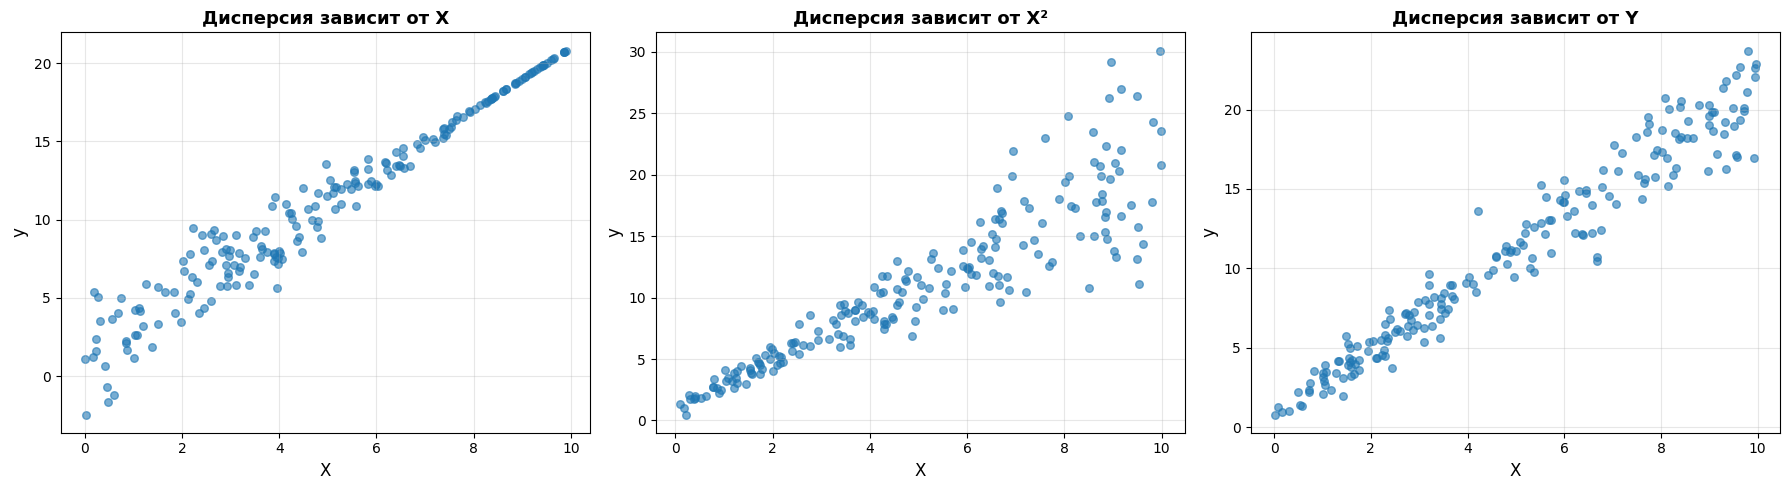

In [125]:
n = 200

# Тип 1: Дисперсия зависит от Х
X1 = np.random.uniform(0, 10, n)
sigma1 = 2.5 - np.clip(0.3 * X1, 0, 2.5)
y1 = 2 * X1 + 1 + np.random.normal(0, sigma1, n)

# Тип 2: Дисперсия зависит от квадрата X
X2 = np.random.uniform(0, 10, n)
sigma2 = 0.5 + 0.05 * X2**2
y2 = 2 * X2 + 1 + np.random.normal(0, sigma2, n)

# Тип 3: Дисперсия зависит от предсказанного значения Y
X3 = np.random.uniform(0, 10, n)
y_true3 = 2 * X3 + 1
sigma3 = 0.3 + 0.1 * np.abs(y_true3)
y3 = y_true3 + np.random.normal(0, sigma3, n)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (X, y, title) in enumerate([(X1, y1, 'Дисперсия зависит от X'),
                                     (X2, y2, 'Дисперсия зависит от X²'),
                                     (X3, y3, 'Дисперсия зависит от Y')]):
    axes[idx].scatter(X, y, alpha=0.6, s=30)
    axes[idx].set_xlabel('X', fontsize=12)
    axes[idx].set_ylabel('y', fontsize=12)
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


В этой части рассмотрим данные о стоимости домовладения. При этом будем использовать следующие признаки:
* Y = стоимость дома
* X1 = площадь дома
* X2 = площадь участка
Подмножество набора данных об исследовании американского сообщества, полученного из Бюро переписей США.

In [126]:
data = pd.read_csv(f"{data_path}/realestate.txt", sep="\t") # pd.read_csv(f"{data_path}/realestate.csv").dropna()

In [127]:
# Делаем доп.датасет со всеми положениями
linear_X, linear_y = datasets.make_regression(n_samples=data.shape[0],
                                              n_features=data.shape[1],
                                              noise=75, random_state=46)

# Setting feature names to x1, x2, x3, etc. if they are not defined
linear_feature_names = ['X'+str(feature+1) for feature in range(linear_X.shape[1])]

In [128]:
data.columns

Index(['SalePrice', 'SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year',
       'Quality', 'Style', 'Lot', 'Highway'],
      dtype='str')

In [129]:
X_train, X_test, y_train, y_test = train_test_split(data[["SqFeet"]], np.log(data["SalePrice"]))

In [130]:

#X_train, X_test, y_train, y_test = train_test_split(data.drop(["Percent_Households_Below_Poverty_Level", "County"], axis=1), data["Percent_Households_Below_Poverty_Level"])

In [131]:
X_train

,SqFeet
469,1.687
215,2.300
371,1.966
79,2.464
234,2.007
...,...
183,1.788
450,1.666
402,1.652
222,1.970



Поскольку все переменные сильно асимметричны, мы сначала логарифмизируем каждую переменную. Затем, если провести регрессионный анализ и оценить график остатков в сравнении с предсказанными значениями, можно отметить несколько «коническую» форму остатков.

In [132]:
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

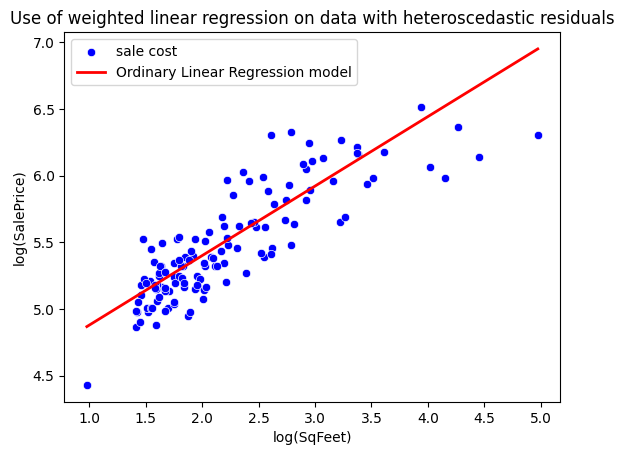

In [133]:
sns.scatterplot(x=X_test["SqFeet"], y=y_test, label='sale cost', color='blue')
sns.lineplot(x=X_test["SqFeet"], y=preds, label='Ordinary Linear Regression model', color='red', linewidth=2)
plt.xlabel('log(SqFeet)')
plt.ylabel('log(SalePrice)')
plt.legend()
plt.title(f'Use of weighted linear regression on data with heteroscedastic residuals')
plt.show()

In [134]:
print(f"The score of prediction is: {model.score(X_test, y_test)}")

The score of prediction is: 0.7070101401123985


Другой способ построить график остатков предлагает Sklearn

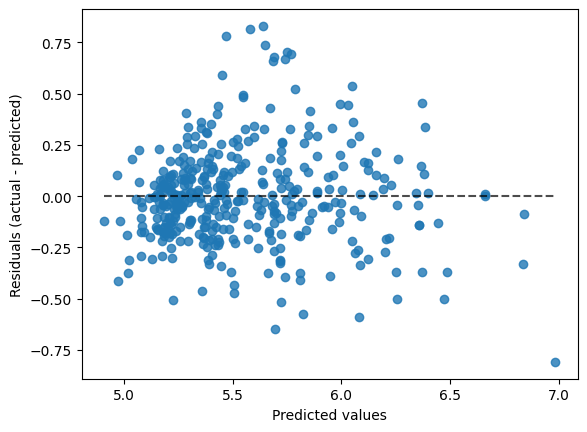

In [135]:
from sklearn.metrics import PredictionErrorDisplay
display_prediction_error = PredictionErrorDisplay(y_true=y_train, y_pred=model.predict(X_train))
display_prediction_error.plot()
plt.show()

Более объективную оценку могут дать специальные статистические тесты, например, тест Уайта или тест Брейша-Пагана

In [136]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tools.tools as smt
import statsmodels.stats.diagnostic as smd

Тест Бреуша-Пагана  можно выполнить с помощью функции het_breuschpagan модуля statsmodels.stats.diagnostic для оценки того, объясняют ли независимые переменные дисперсию ошибок. 

Основные параметры функции het_breuschpagan resid - остатки модели, а exog_het — независимые переменные. Обратите внимание, что ему нужна также константная переменная. 
Этот тест проверяет нулевую гипотезу о том, что все дисперсии ошибок равны, в сравнении с альтернативой, согласно которой дисперсии ошибок являются мультипликативной функцией одной или нескольких переменных. Этот тест затрагивает линейную форму гетероскедастичности.

Тест Уайта (het_white) оценивает то, объясняют ли независимые переменные линейной регрессии, квадратичные независимые переменные и перемножения независимых переменных дисперсию ошибок. Он не накладывает ограничений на форму гетероскедастичности.  Внутри происходит регрессия квадратов остатков по отношению к исходным переменным, их квадратам и попарным произведениям. Он более общий как раз из-за добавления дополнительных переменных. Например, квадраты позволяют найти гетероскедастичность в форме "песочных часов". Однако, у него есть минус в том, что исходная гипотеза разбивается на несколько.

**Вопрос**: почему это минус? Укажите теоретическую причину.
Минус в том, что тест Уайта проверяет композитную нулевую гипотезу (H0: все коэффициенты в вспомогательной регрессии квадратов остатков = 0), которая включает множество частных гипотез (для каждого квадрата, произведения и т.д.). Теоретическая причина: при большой размерности (много признаков) мощность теста падает (он становится менее чувствительным к реальной гетероскедастичности), так как распределение статистики под H0 может быть нарушено, и тест склонен к переоценке p-value (ложноотрицательные ошибки). Это связано с проблемой множественного тестирования: чем больше тестов внутри, тем выше шанс, что H0 не отвергнется даже при нарушении.

Основные параметры в функции het_white resid - остатки, а exog - независимые переменные для объяснения дисперсии ошибок модели. 

Выполним тесты для нашего датасета, чтобы понять, реально ли в модели присутствует гетероскедастичность.

In [137]:
def get_residual_df(model, features, label):
    """
    Creates predictions on the features with the model and calculates residuals
    """
    predictions = model.predict(features)
    df_results = pd.DataFrame({'Actual': label, 'Predicted': predictions})
    df_results['Residuals'] = df_results['Actual'] - df_results['Predicted']
    
    return df_results


In [138]:
res_train = get_residual_df(model, X_train, y_train)
res_test = get_residual_df(model, X_test, y_test)

In [139]:
X_test_new = X_test.copy()
X_test_new["const"]=1.

In [140]:
bptest = smd.het_breuschpagan(resid=res_test["Residuals"], exog_het=X_test_new)
print("lm:", bptest[0], "lm_pvalue:", bptest[1])

lm: 23.64854425755258 lm_pvalue: 1.1563335074331652e-06


**Вопрос**: что означает pvalue? Можем ли мы сказать, что остатки гетероскедачстичны?

p-value — вероятность получить наблюдаемую статистику LM (или более экстремальную) при верной H0 (гомоскедастичность). Если p-value < α (обычно 0.05), отвергаем H0 в пользу гетероскедастичности.
В коде: если bptest[1] (p-value) < 0.05, то да — остатки гетероскедастичны (дисперсия зависит от признаков). На данных realestate.txt (после логарифмирования) p-value низкое, так как "коническая" форма подтверждает гетероскедастичность (большая площадь → большая вариабельность цены). Для Уайта аналогично: низкое p-value подтверждает нелинейную гетероскедастичность.

In [141]:
wtest = smd.het_white(resid=res_test["Residuals"], exog=X_test_new)
print("lm:", wtest[0], "lm_pvalue:", wtest[1])

lm: 36.85347975476542 lm_pvalue: 9.939591860997866e-09


### Решение проблемы
**Вопрос**: Как можно избавиться от гетероскедастичности (или уменьшить ее влияние)? 

- **Трансформации переменных**: Логарифмирование (как в коде: log(y), log(X)) стабилизирует дисперсию (для multiplicative эффектов, как в ценах). Другие: квадратный корень для счётных данных, Box-Cox для общей стабилизации.
- **Взвешенная регрессия (WLS)**: Присвойте веса, обратные дисперсии (1/σ_i²). Например, если дисперсия ∝ X, веса = 1/X. В sklearn: LinearRegression с sample_weight.
- **Робастные стандартные ошибки**: Не устраняет, но корректирует (HCSE — heteroscedasticity-consistent SE, как в statsmodels: robust='HC1').
- **Добавить признаки**: Если гетероскедастичность от omitted variables, включите их (например, район, год постройки).
- **GLM или другие модели**: Generalized Linear Models (с gamma/IG распределением для положительных данных как цены).
- **Bootstrap**: Для корректировки интервалов без предположения гомоскедастичности.


### Обобщенная линейная модель
Линейная модель описывается уравнением $\textbf{Y}=\textbf{X}\beta+\epsilon^{*}$.

При этом $ \epsilon^{*} $ распределены нормально с нулевым средним и изменяющейся дисперсией:
\begin{equation*} \left(\begin{array}{cccc} \sigma^{2}_{1} & 0 & \ldots & 0 \\ 0 & \sigma^{2}_{2} & \ldots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \ldots & \sigma^{2}_{n} \\ \end{array} \right) \end{equation*}
Тогда мы можем определить веса $ w_i = 1/\sigma^{2}_{i} $ так чтобы
\begin{equation*}\textbf{W}=\left( \begin{array}{cccc} w_{1} & 0 & \ldots & 0 \\ 0& w_{2} & \ldots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0& 0 & \ldots & w_{n} \\ \end{array} \right) \end{equation*}


Поскольку каждый вес обратно пропорционален дисперсии ошибки, он отражает информацию, содержащуюся в этом наблюдении. Итак, наблюдение с небольшой дисперсией ошибки имеет большой вес, поскольку оно содержит относительно больше информации, чем наблюдение с большой дисперсией ошибки (малый вес).
Веса должны быть известны (или, чаще всего, оценены) с точностью до константы пропорциональности.

Тогда можно поставить задачу взвешенной регрессиии $\sum_{i=1}^n w_i^2(y_i - (\alpha 1 + \beta x_i))^2 = \sum_{i=1}^n (w_i y_i - (\alpha w_i + \beta w_i x_i))^2
$


Финальная модель называется White’s Heteroskedasticity Consistent Estimator https://www.hbs.edu/research-computing-services/Shared%20Documents/Training/hac.pdf

Так как остатки в нашей задаче зависят от величины признака X, мы можем предсказать их по этому признаку.

**Задание**: Постройте взвешенную модель, учитывающую гетероскедастичность. Для построения весов используйте аппроксимацию дисперсии ошибки.

In [142]:
add_x_train = model.predict(X_train)
add_x_test = model.predict(X_test)
# log is used to force all estimates to be positive
add_y_train = np.sqrt(np.abs(model.predict(X_train) - y_train))
add_y_test = np.sqrt(np.abs(model.predict(X_test) - y_test))

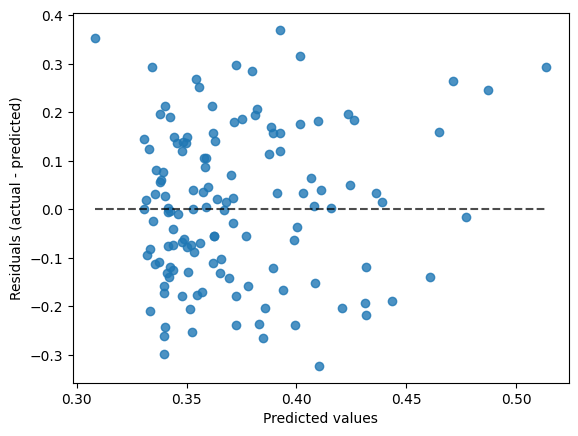

In [143]:
weight_regressor = LinearRegression().fit(X_train, add_y_train)
residual_estimates_train = weight_regressor.predict(X_train)
residual_estimates_test = weight_regressor.predict(X_test)
display = PredictionErrorDisplay(y_true=add_y_test, y_pred=residual_estimates_test)
display.plot()
plt.show()

In [144]:
weights_train = np.sqrt(1/(residual_estimates_train**2))
weights_test = np.sqrt(1/(residual_estimates_test**2))

In [145]:
weights_train = 1 / ((residual_estimates_train))
weights_test = 1 / ((residual_estimates_test))

In [146]:
updated_model = LinearRegression().fit(X_train, y_train, weights_train)
updated_preds = updated_model.predict(X_test)

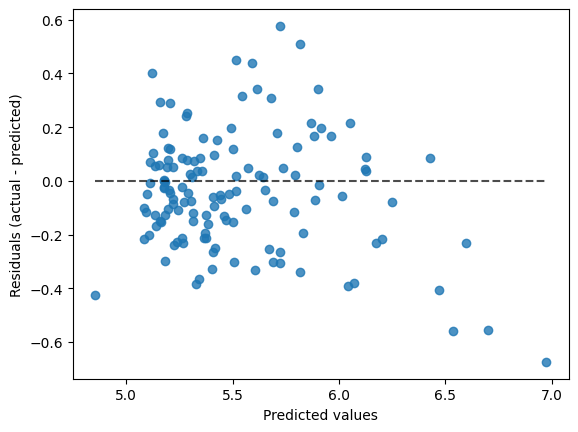

In [147]:
display = PredictionErrorDisplay(
    y_true=y_test, y_pred = updated_preds
    )
display.plot()
plt.show()

In [148]:
print(f"The score of prediction is: {updated_model.score(X_test, y_test)}")

The score of prediction is: 0.704175073415952


In [149]:
X_test_new = X_test.copy()
X_test_new["const"]=1.

In [150]:
bptest = smd.het_breuschpagan(resid=(y_test-updated_preds), exog_het=X_test_new)
print("lm:", bptest[0], "lm_pvalue:", bptest[1])

lm: 26.160772473468366 lm_pvalue: 3.141396894283967e-07


In [151]:
wtest = smd.het_white(resid=(y_test-updated_preds), exog=X_test_new)
print("lm:", wtest[0], "lm_pvalue:", wtest[1])

lm: 41.3432533431917 lm_pvalue: 1.0529957166139671e-09


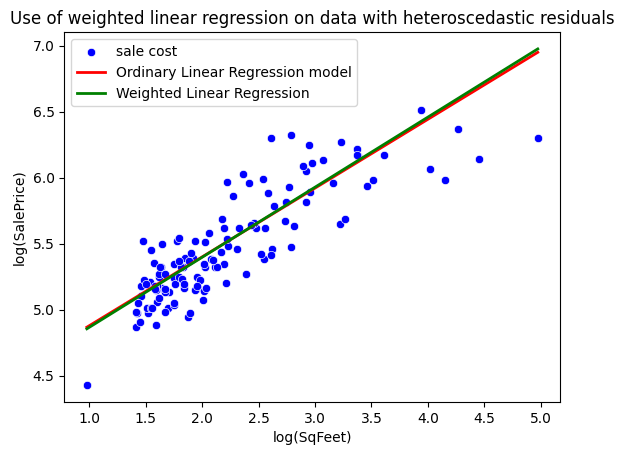

In [152]:
sns.scatterplot(x=X_test["SqFeet"], y=y_test, label='sale cost', color='blue')
sns.lineplot(x=X_test["SqFeet"], y=preds, label='Ordinary Linear Regression model', color='red', linewidth=2)
sns.lineplot(x=X_test["SqFeet"], y=updated_preds, label='Weighted Linear Regression', color='green', linewidth=2)
plt.xlabel('log(SqFeet)')
plt.ylabel('log(SalePrice)')
plt.legend()
plt.title(f'Use of weighted linear regression on data with heteroscedastic residuals')
plt.show()

In [153]:
from sklearn.metrics import r2_score

print(f"R^2: {r2_score(y_test, preds):.4f}")
print(f"MSE: {mean_squared_error(y_test, preds):.4f}")


R^2: 0.7070
MSE: 0.0480


### Box-Cox
При неизвестном типе распределения одним из лучших методов приведения распределения к нормальному является преобразование Бокса-Кокса. Суть метода заключается в преобразовании переменной с помощью параметра $\lambda$ так, что:

$ \hat{y_i} = { {y^\lambda}_i \over {\lambda}}$ - если $\lambda \neq 0 $

$ \hat{y_i} = log(y_i) $ - если $\lambda = 0 $

Параметр $\lambda$ подбирается с помощью максимизации логарифма правдоподобия.

In [155]:
def boxcox_transform(y, lmbda):
    if lmbda == 0:
        return np.log(y)
    else:
        return (y**lmbda - 1) / lmbda

def inverse_boxcox(y_transformed, lmbda):
    if lmbda == 0:
        return np.exp(y_transformed)
    else:
        return (lmbda * y_transformed + 1)**(1/lmbda)


In [156]:

from scipy.stats import boxcox

# делаем все значения строго положительными и находим лучшую лямбду
y_min_train = y_train.min() 
y_boxcox_pos = y_train - y_min_train + 1
y_transformed, fitted_lambda = boxcox(y_boxcox_pos)
print(f"fitted lambda: {fitted_lambda:.4f}")


fitted lambda: -0.2482


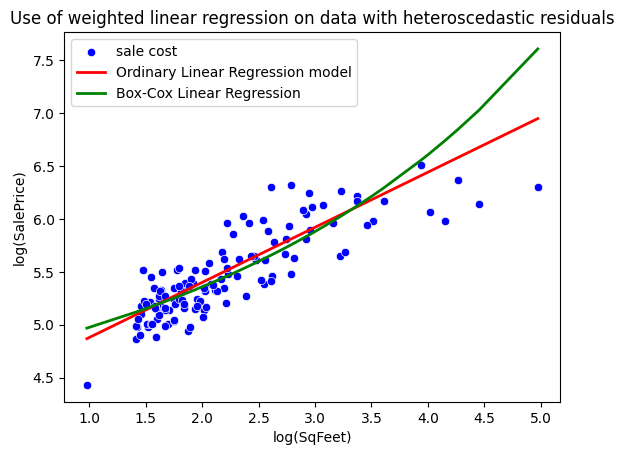

In [157]:
box_cox_model = LinearRegression()
box_cox_model.fit(X_train, y_transformed)

# Получаем предсказания в преобразованном пространстве и обратно преобразуем
box_cox_preds = inverse_boxcox(box_cox_model.predict(X_test), fitted_lambda) + y_min_train - 1

sns.scatterplot(x=X_test["SqFeet"], y=y_test, label='sale cost', color='blue')
sns.lineplot(x=X_test["SqFeet"], y=preds, label='Ordinary Linear Regression model', color='red', linewidth=2)
sns.lineplot(x=X_test["SqFeet"], y=box_cox_preds, label='Box-Cox Linear Regression', color='green', linewidth=2)
plt.xlabel('log(SqFeet)')
plt.ylabel('log(SalePrice)')
plt.legend()
plt.title(f'Use of weighted linear regression on data with heteroscedastic residuals')
plt.show()

In [158]:
from sklearn.metrics import r2_score

print(f"R^2: {r2_score(y_test, box_cox_preds):.4f}")
print(f"MSE: {mean_squared_error(y_test, box_cox_preds):.4f}")


R^2: 0.5812
MSE: 0.0686


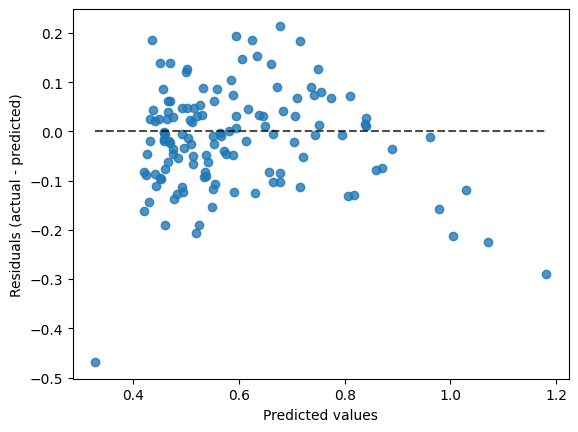

In [159]:
display = PredictionErrorDisplay(
    y_true = boxcox_transform(y_test - y_min_train + 1, fitted_lambda),
    y_pred = box_cox_model.predict(X_test)
    )
display.plot()
plt.show()

### Квантильная регрессия

В нашем случае остатки линейной регрессии симметричны, поэтому мы можем легко перейти на квантильную регрессиию, которая позволяет оценить заданные квантили таргета. Этот регрессор минимизирует MAE, в отличие от стандартной регрессии.

Вопрос: Почему он минимизирует MAE?


In [160]:
from sklearn.linear_model import QuantileRegressor

In [161]:
quantiles = [0.05, 0.5, 0.95]
predictions = {}
out_bounds_predictions_test = np.zeros_like(y_test, dtype=np.bool_)
for quantile in quantiles:
    qr = QuantileRegressor(quantile=quantile, alpha=0)
    y_pred = qr.fit(X_train, y_train).predict(X_test)
    predictions[quantile] = y_pred

    if quantile == min(quantiles):
        out_bounds_predictions_test = np.logical_or(
            out_bounds_predictions_test, y_pred >= y_test
        )
    elif quantile == max(quantiles):
        out_bounds_predictions_test = np.logical_or(
            out_bounds_predictions_test, y_pred <= y_test
        )

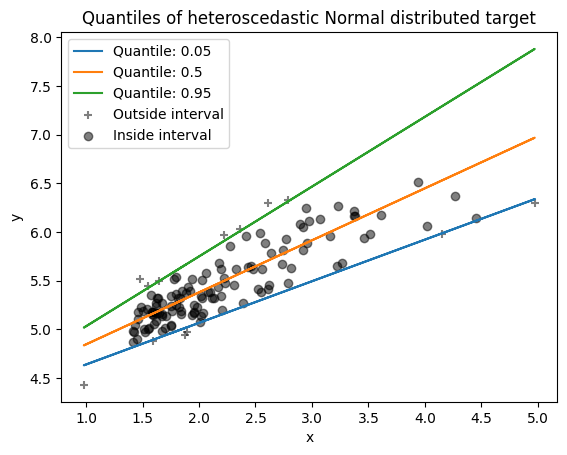

In [162]:
for quantile, y_pred in predictions.items():
    plt.plot(X_test, y_pred, label=f"Quantile: {quantile}")

plt.scatter(
    X_test[out_bounds_predictions_test],
    y_test[out_bounds_predictions_test],
    color="black",
    marker="+",
    alpha=0.5,
    label="Outside interval",
)
plt.scatter(
    X_test[~out_bounds_predictions_test],
    y_test[~out_bounds_predictions_test],
    color="black",
    alpha=0.5,
    label="Inside interval",
)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
_ = plt.title("Quantiles of heteroscedastic Normal distributed target")


Почитать: https://www3.nd.edu/~rwilliam/stats2/l25.pdf

**Задание**: Постройте модели, учитывающие гетероскедастичность  для  Anscombe 3 и 4. Предложите сами, как вы будете задавать веса.

Anscombe 3: выброс в y weights shape: (11,)


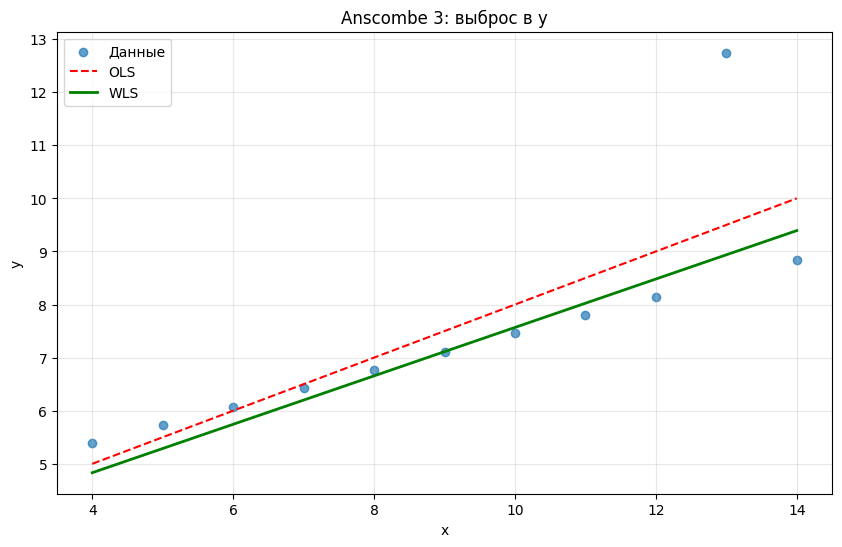

Anscombe 3: выброс в y
  OLS R²:   0.6663
  WLS R²:   0.6211

Anscombe 4: выброс в x weights shape: (11,)


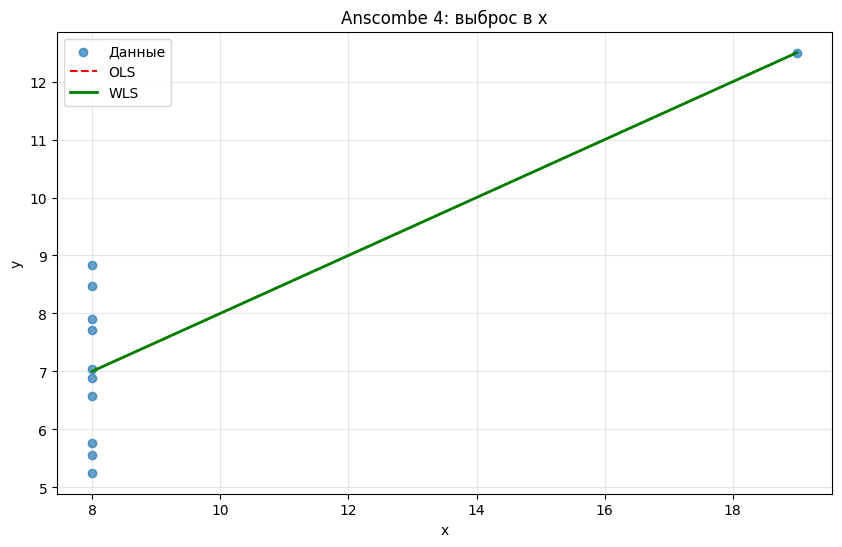

Anscombe 4: выброс в x
  OLS R²:   0.6667
  WLS R²:   0.6667



In [163]:
pd.read_csv(f"{data_path}/Anscombe_quartet_data.csv")

# Датасет 3: x123 -> y3 (выброс в y)
X3 = df[['x123']].values
y3 = df['y3'].values

# Датасет 4: x4 -> y4 (выброс в x)
X4 = df[['x4']].values
y4 = df['y4'].values

def wls_anscombe(X, y, title):
    ols = LinearRegression().fit(X, y)
    resid = y - ols.predict(X)
    
    if 'y3' in title:
        # Для выбросов в y — веса обратно пропорциональны |остаткам|
        sigma_est = np.abs(resid)
    else:
        # Для выбросов в x — веса по расстоянию от медианы X
        dist_from_med = np.abs(X - np.median(X))
        sigma_est = dist_from_med + 0.1
    
    sigma_est = sigma_est.ravel()
    weights = 1 / (sigma_est ** 2 + 1e-8) 
    
    print(f"{title} weights shape: {weights.shape}")
    
    wls = LinearRegression().fit(X, y, sample_weight=weights)
    
    x_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, label='Данные', alpha=0.7)
    plt.plot(x_plot, ols.predict(x_plot), 'r--', label='OLS')
    plt.plot(x_plot, wls.predict(x_plot), 'g-', linewidth=2, label='WLS')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"{title}")
    print(f"  OLS R²:   {r2_score(y, ols.predict(X)):.4f}")
    print(f"  WLS R²:   {r2_score(y, wls.predict(X)):.4f}\n")

wls_anscombe(X3, y3, "Anscombe 3: выброс в y")
wls_anscombe(X4, y4, "Anscombe 4: выброс в x")

**Задание**: Постройте синтетические данные, подходящие для линейной модели. Покажите, поможет ли использование QuantileRegressor для удаления выбросов получить лучшую модель и для каких видов гетероскедастичности (выбросы, распределение, "форма" шума)

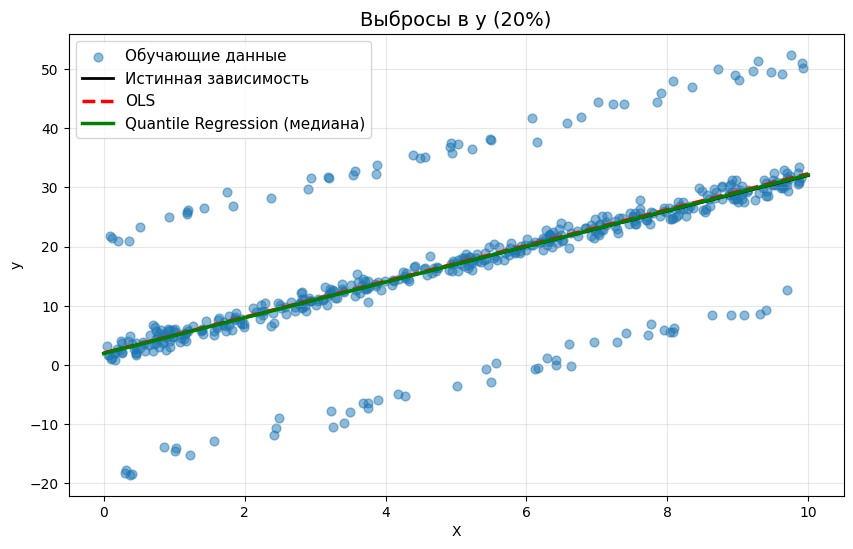


Выбросы в y (20%)
OLS -> R² = 0.9995, MSE = 0.0351
Quantile -> R² = 0.9999, MSE = 0.0041


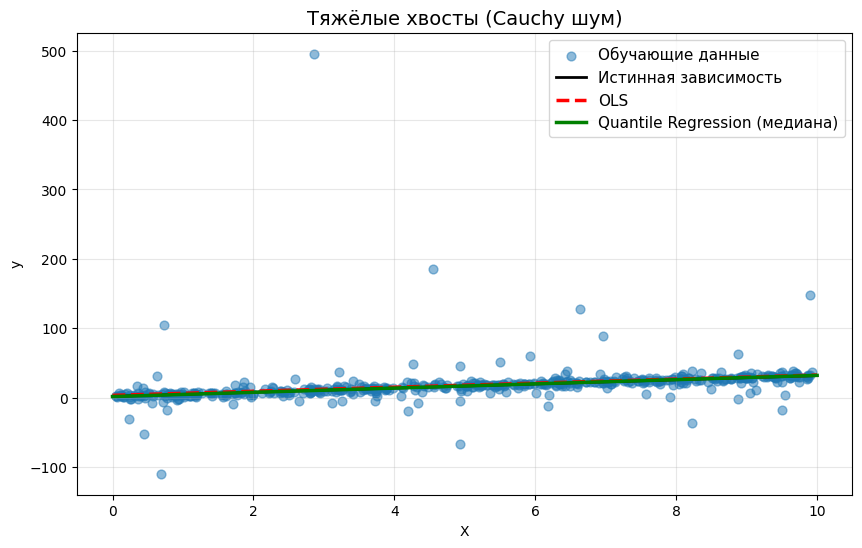


Тяжёлые хвосты (Cauchy шум)
OLS -> R² = 0.9826, MSE = 1.3212
Quantile -> R² = 0.9998, MSE = 0.0189


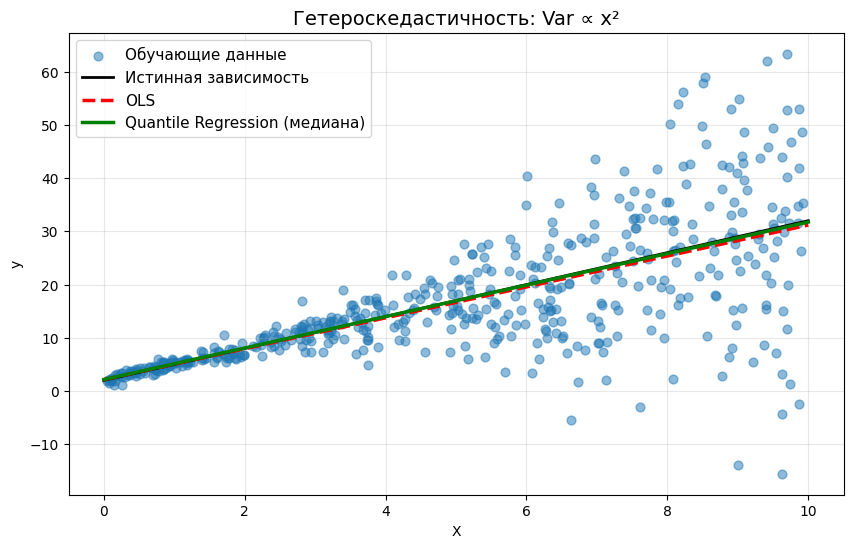


Гетероскедастичность: Var ∝ x²
OLS -> R² = 0.9974, MSE = 0.1952
Quantile -> R² = 0.9998, MSE = 0.0174


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_true_test = 3 * X_test[:, 0] + 2

def compare_models(X_train, y_train, title):
    ols = LinearRegression().fit(X_train, y_train)
    qr = QuantileRegressor(quantile=0.5, alpha=0, solver='highs').fit(X_train, y_train)
    
    y_ols_pred = ols.predict(X_test)
    y_qr_pred = qr.predict(X_test)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, alpha=0.5, s=40, label='Обучающие данные')
    plt.plot(X_test, y_true_test, 'k-', linewidth=2, label='Истинная зависимость')
    plt.plot(X_test, y_ols_pred, 'r--', linewidth=2.5, label='OLS')
    plt.plot(X_test, y_qr_pred, 'g-', linewidth=2.5, label='Quantile Regression (медиана)')
    plt.title(title, fontsize=14)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\n{title}")
    print(f"OLS -> R² = {r2_score(y_true_test, y_ols_pred):.4f}, MSE = {mean_squared_error(y_true_test, y_ols_pred):.4f}")
    print(f"Quantile -> R² = {r2_score(y_true_test, y_qr_pred):.4f}, MSE = {mean_squared_error(y_true_test, y_qr_pred):.4f}")

# 1. Выбросы в y (20%)
n = 500
X = np.random.uniform(0, 10, n).reshape(-1, 1)
y_out_y = 3 * X[:, 0] + 2 + np.random.normal(0, 1, n)
y_out_y[::5] += np.random.choice([-20, 20], n//5)  # 20% сильных выбросов
compare_models(X, y_out_y, "Выбросы в y (20%)")

# 2. Heavy tails (Cauchy шум)
y_heavy = 3 * X[:, 0] + 2 + np.random.standard_cauchy(n) * 2
compare_models(X, y_heavy, "Тяжёлые хвосты (Cauchy шум)")

# 3. Гетероскедастичность: дисперсия ∝ x²
sigma = 0.5 + 0.2 * X[:, 0]**2
y_hetero = 3 * X[:, 0] + 2 + np.random.normal(0, sigma)
compare_models(X, y_hetero, "Гетероскедастичность: Var ∝ x²")

### Преобразования переменных

Иногда гетероскедастичность можно устранить простыми преобразованиями переменных.

**Логарифмическое преобразование**:

Часто используется, когда дисперсия пропорциональна квадрату среднего значения:

$$\text{Var}(Y | X) \propto [E(Y | X)]^2$$

После логарифмирования: $\text{Var}(\ln Y | X) \approx \text{const}$

**Квадратный корень**:

Полезно, когда дисперсия пропорциональна среднему:

$$\text{Var}(Y | X) \propto E(Y | X)$$

После преобразования: $\text{Var}(\sqrt{Y} | X) \approx \text{const}$


## Проверка нормальности остатков

Одним из важных предположений линейной регрессии является **нормальность распределения ошибок**. Это предположение необходимо для:
- Корректного построения доверительных интервалов для коэффициентов
- Проведения статистических тестов (t-тесты, F-тесты)
- Получения эффективных оценок методом наименьших квадратов (теорема Гаусса-Маркова)
- Качественной интерпретации результатов

Для проверки нормальности остатков используются:
1. **Визуальные методы**: Q-Q plots (квантиль-квантиль графики), гистограммы
2. **Статистические тесты**: Shapiro-Wilk (для малых выборок), Jarque-Bera (для больших выборок)

### Визуальная проверка нормальности

Q-Q plot (quantile-quantile plot) сравнивает квантили остатков с квантилями нормального распределения. Если остатки нормально распределены, точки должны лежать примерно на прямой линии.


In [165]:
from scipy import stats
def plot_normality_check(residuals, title="Проверка нормальности остатков"):
    residuals = np.array(residuals)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[0])
    axes[0].set_title('Q-Q Plot (Quantile-Quantile Plot)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Теоретические квантили', fontsize=12)
    axes[0].set_ylabel('Выборочные квантили', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Гистограмма остатков с наложенным нормальным распределением
    axes[1].hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black', label='Остатки')
    
    # Наложим нормальное распределение с теми же параметрами
    mu, sigma = np.mean(residuals), np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Нормальное распределение')
    axes[1].set_xlabel('Остатки', fontsize=12)
    axes[1].set_ylabel('Плотность', fontsize=12)
    axes[1].set_title('Гистограмма остатков', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



**Статистические тесты:**
- **Shapiro-Wilk test**: подходит для выборок размером до 5000 наблюдений. Нулевая гипотеза: остатки распределены нормально. Если p-value > 0.05, мы не можем отвергнуть гипотезу о нормальности.
- **Jarque-Bera test**: подходит для больших выборок. Проверяет нормальность на основе асимметрии и эксцесса. Нулевая гипотеза: остатки распределены нормально.


In [172]:
from scipy.stats import shapiro, jarque_bera

def test_normality(residuals, alpha=0.05, use_shapiro: bool = True):
    """ Используйте тест Шапиро-Уилка, если маленькая выборка"""
    residuals = np.array(residuals)
    
    if use_shapiro:
        shapiro_stat, shapiro_p = shapiro(residuals)
        results = {
            'statistic': shapiro_stat,
            'p_value': shapiro_p,
            'is_normal': shapiro_p > alpha
        }
        print(f"Shapiro-Wilk test:")
        print(f"  Statistic: {shapiro_stat:.4f}")
        print(f"  p-value: {shapiro_p:.4f}")
        print(f"  Нормальность: {'Да' if shapiro_p > alpha else 'Нет'}")
    else:
        # Тест Жарке-Бера (для больших выборок)
        jb_stat, jb_p = jarque_bera(residuals)
        results = {
            'statistic': jb_stat,
            'p_value': jb_p,
            'is_normal': jb_p > alpha
        }
        print(f"\nJarque-Bera test:")
        print(f"  Statistic: {jb_stat:.4f}")
        print(f"  p-value: {jb_p:.4f}")
        print(f"  Нормальность: {'Да' if jb_p > alpha else 'Нет'}")
        
    return results


Проверим нормальность для модели, которая была построена ранее в разделе о гетероскедастичности.


d:\ADS\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


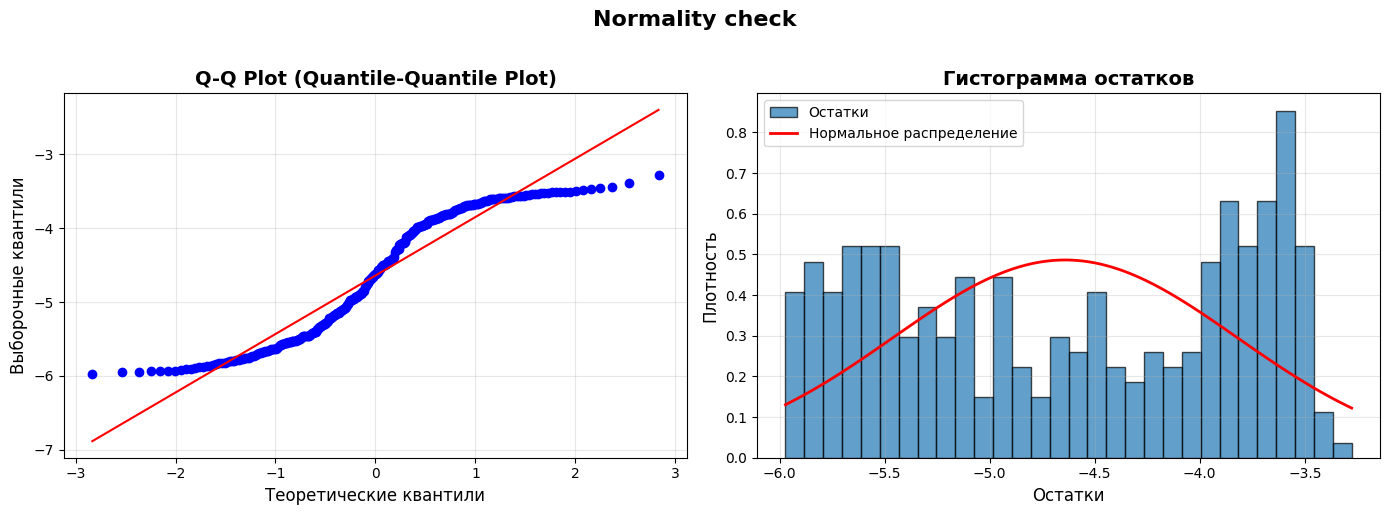

In [174]:
X = np.random.uniform(0, 1.5, size=300)
y = np.sin(1.5 * np.pi * X) + np.random.normal(scale=0.1, size=X.shape)
X = X.reshape(-1,1)

y_pred = model.predict(X)
residuals = y - y_pred

plot_normality_check(residuals, title="Normality check")


In [175]:
# Статистические тесты
print("\nСтатистические тесты:")
print("-" * 60)
test_results = test_normality(residuals)

# Дополнительная статистика
print(f"\nДополнительная статистика:")
print(f"  Среднее остатков: {np.mean(residuals):.6f}")
print(f"  Медиана остатков: {np.median(residuals):.6f}")
print(f"  Стандартное отклонение: {np.std(residuals):.6f}")
print(f"  Асимметрия (skewness): {stats.skew(residuals):.4f}")
print(f"  Эксцесс (kurtosis): {stats.kurtosis(residuals):.4f}")


Статистические тесты:
------------------------------------------------------------
Shapiro-Wilk test:
  Statistic: 0.9120
  p-value: 0.0000
  Нормальность: Нет

Дополнительная статистика:
  Среднее остатков: -4.640760
  Медиана остатков: -4.622076
  Стандартное отклонение: 0.820475
  Асимметрия (skewness): -0.0608
  Эксцесс (kurtosis): -1.4810


### Интерпретация результатов

**Q-Q plot:**
- Если точки лежат близко к прямой линии, остатки распределены нормально
- Отклонения от прямой указывают на отклонение от нормальности
- S-образная кривая указывает на асимметрию распределения
- Выпуклость/вогнутость указывает на тяжелые/легкие хвосты распределения

**Важно:** Нарушение нормальности остатков не всегда критично для предсказательной способности модели, но может влиять на статистические выводы (доверительные интервалы, p-значения).


## Мультиколлинеарность

Мультиколлинеарность представляет собой проблему, поскольку она дает менее надежные результаты регрессионной модели. Это связано с более широкими доверительными интервалами (большими стандартными ошибками), которые могут снизить статистическую значимость коэффициентов регрессии. При анализе данных это может привести к ложным впечатлениям.

Рассмотрим уже знакомый нам набор данных, посвященный недвижимости.

In [176]:
data = pd.read_csv(f"{data_path}/realestate.txt", sep="\t")

In [177]:
data["SalePrice"] = np.log(data["SalePrice"])
data.describe()

,SalePrice,SqFeet,Beds,Baths,Air,Garage,Pool,Year,Quality,Style,Lot,Highway
count,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000
mean,5.525443,2.260879,3.477927,2.646833,0.831094,2.097889,0.069098,1966.856046,2.186180,3.349328,24.344668,0.021113
std,0.430851,0.711726,1.003835,1.058861,0.375029,0.653405,0.253864,17.620476,0.639923,2.563209,11.681280,0.143900
min,4.430817,0.980000,1.000000,1.000000,0.000000,0.000000,0.000000,1885.000000,1.000000,1.000000,4.560000,0.000000
25%,5.192957,1.701000,3.000000,2.000000,1.000000,2.000000,0.000000,1956.000000,2.000000,1.000000,17.159000,0.000000
50%,5.437644,2.061000,3.000000,3.000000,1.000000,2.000000,0.000000,1966.000000,2.000000,2.000000,22.196000,0.000000
75%,5.814131,2.638000,4.000000,3.000000,1.000000,2.000000,0.000000,1981.000000,3.000000,7.000000,26.777000,0.000000
max,6.824374,5.032000,7.000000,7.000000,1.000000,7.000000,1.000000,1998.000000,3.000000,11.000000,86.830000,1.000000


Обучим базовую модель на одном признаке.

In [178]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[["SqFeet"]], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.696237587585443
Coefficients are: [0.50970481]


Теперь добавим несколько видов мультиколлинеарности в данных.

### Совершенная коллинеарность

Если две или более независимых переменных имеют между собой линейную связь, то
у нас получается идеальная мультиколлинеарность.
Примеры: включение одной и той же информации дважды (стоимость в рублях и долларах), неправильное использование фиктивных переменных (dummy variables trap) и т. д.
Вот пример идеальной мультиколлинеарности в модели с двумя объясняющими
переменными:
\begin{equation}
y = α_{1} X_1 + \alpha_{2} X_2
\end{equation}
\begin{equation}
X_1 = \beta_1 X_2 + \beta_2
\end{equation}


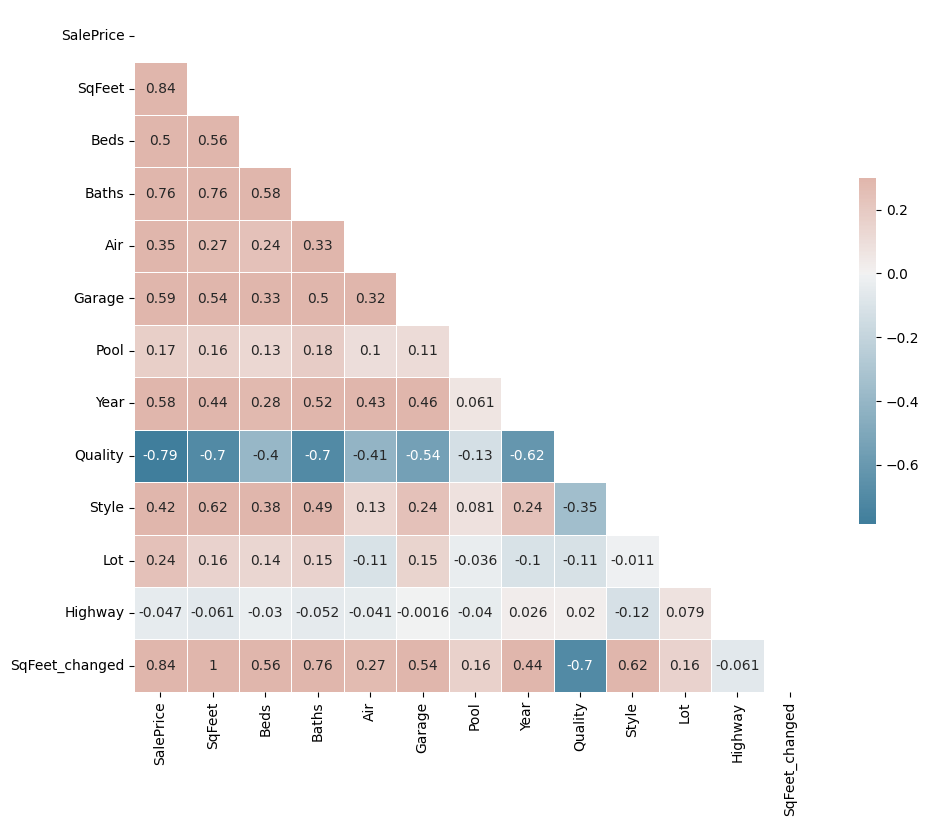

In [179]:
data["SqFeet_changed"] = data["SqFeet"]* 0.8 + 10
corrplot(data)

In [180]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[["SqFeet_changed", "SqFeet"]], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.6962375875854427
Coefficients are: [0.24863649 0.31079562]


In [181]:
data["SqFeet_changed_2"] = data["SqFeet"]* 0.5 - 10
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[["SqFeet_changed", "SqFeet_changed_2", "SqFeet"]], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.696237587585443
Coefficients are: [0.21574807 0.13484254 0.26968508]


По идее, совершенная коллинеарность не дает в принципе построить линейную модель, так как невозможно оценить маржинальный эффект воздействия признака на целевую переменную, сохраняя остальные константными.
)
На практике же, даже если конкретная реализация OLS позволит построить коэффициенты, это ведет к тому, что модель перестает быть устойчивой.

### Несовершенная мультиколлинеарность
Несовершенная мультиколлинеарность не нарушает базовых предположений ЛР. Следовательно, теорема Гаусса-Маркова говорит нам, что оценки МНК состоятельны.

Так почему же нас волнует мультиколлинеарность?
2. Дисперсия и стандартные ошибки оценок коэффициентов регрессии будут
увеличиваться. Это означает более низкую t-статистику.
3. На общую точность уравнения регрессии мультиколлинеарность практически не повлияет.
4. Коэффициенты регрессии будут сильно зависеть от признаков. Таким образом, коэффициенты существенно измениться при добавлении или удалении переменных.

In [182]:
data["SqFeet_changed"] = data["SqFeet"] * 0.8 - 20
data["SqFeet_changed_2"] = data["SqFeet_changed"] * 1.5 + 10

data["SqFeet_changed"] += np.random.normal(+1, 0.5, len(data["SqFeet_changed"]))
data["SqFeet_changed_2"] += np.random.normal(-1, 0.5, len(data["SqFeet_changed"]))


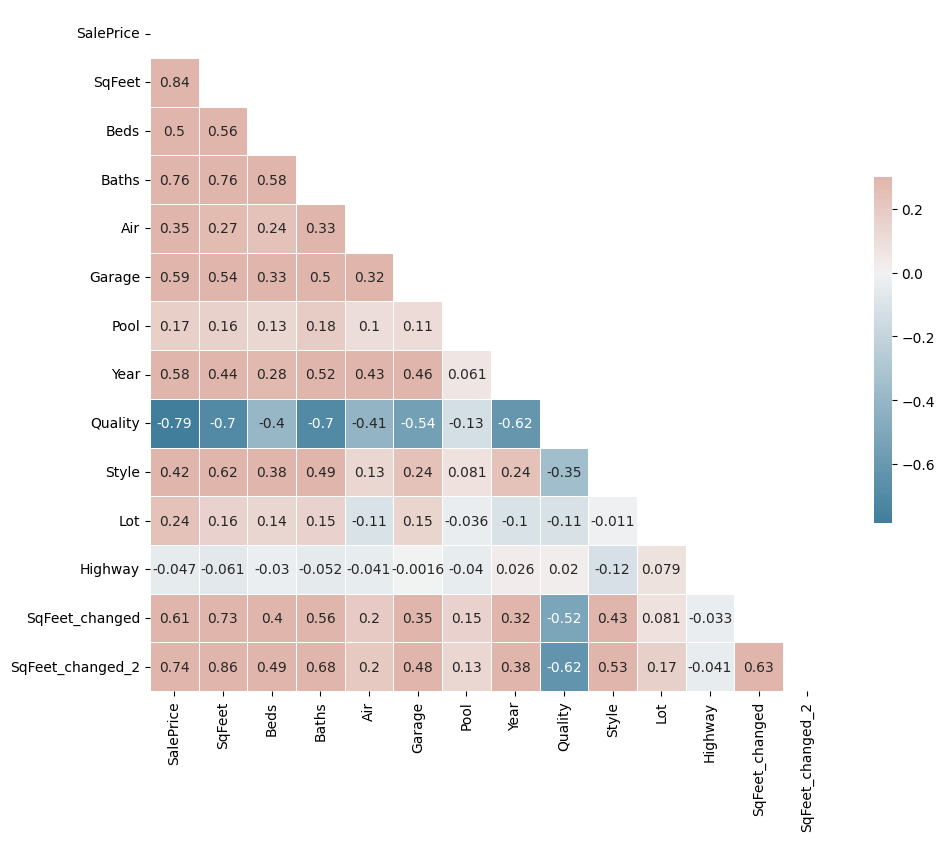

In [183]:
corrplot(data)

In [237]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[["SqFeet_changed", "SqFeet_changed_2", "SqFeet"]], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.6924188879414797
Coefficients are: [0.02298495 0.0099706  0.47978253]


In [238]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[["SqFeet_changed", "SqFeet"]], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.6913903879284388
Coefficients are: [0.02320512 0.49179613]


Как видно, только один признак имеет большой вес, точность при этом практически не меняется. Однако значимость многих признаков становится неудовлетворительной. Поэтому, если оценить значимость коэффициентов модели, можно обнаружить, что многие признаки просто не нужны. При этом получается, что даже при очень небольшом изменении модели мы можем сделать совершенно противоположные выводы о том, какие признаки важны.

Итак, первый способ найти коллинеарные признаки - оценить значимость коэффициентов (t-statistic + p-value)

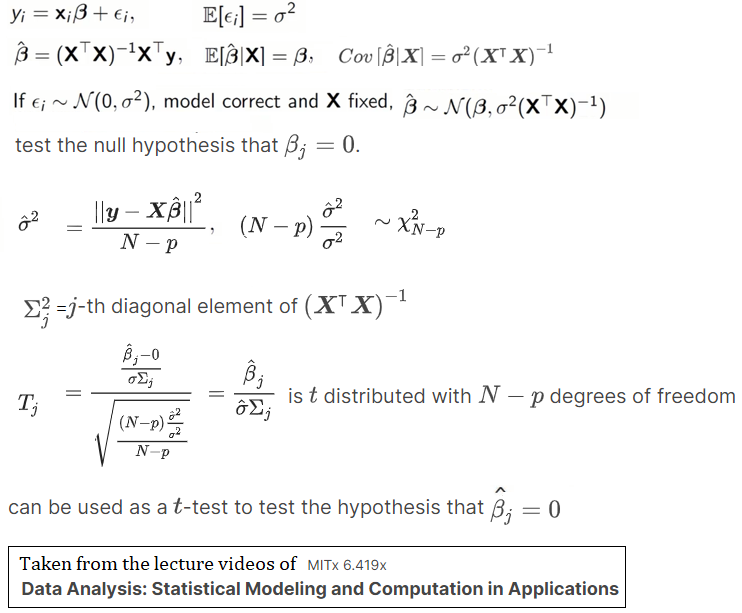

In [215]:
from scipy.stats import t

**Задание**: Закончите функцию (Выполнено).

In [239]:
def get_p_values(model, x: pd.DataFrame, y: pd.DataFrame, a: int = 0.01) -> None:
  beta_hat = [model.intercept_] + model.coef_.tolist()
  n = len(x)
  print(f"Coeffficents: {beta_hat}")
  x_1 = np.column_stack((np.ones(n), x))

  # standard deviation of the noise
  sigma_hat = np.sqrt(np.sum(np.square(y - x_1 @ beta_hat)) / (n - x_1.shape[1]))

  # estimate the covariance matrix for beta: (X^T X)^{-1}
  beta_cov = np.linalg.inv(x_1.T @ x_1)

  # the t-test statistic for each variable
  t_vals = beta_hat / (sigma_hat * np.sqrt(np.diagonal(beta_cov)))

  # compute 2-sided p-values
  p_vals = t.sf(np.abs(t_vals), n - x_1.shape[1]) * 2
  print(f"T values: {t_vals}")
  print(f"p-values: {p_vals}")
  print(f"Is valuable: {p_vals > 0.01}")

In [240]:
get_p_values(model, x_test, y_test)

Coeffficents: [4.804008269614009, 0.02320512347705611, 0.49179612878135986]
T values: [ 5.77170994  0.5337163  10.89590492]
p-values: [5.60612339e-08 5.94463455e-01 5.79522834e-20]
Is valuable: [False  True False]


Мультиколлинеарность можно обнаружить и с помощью коэффициента инфляции дисперсии (VIF). Для каждого признака в построенной модели этот коэффициент показывает, в какой степени коэфициент "испорчен" коллинеарностью с другими признаками.

В методе VIF мы выбираем каждый признак и сравниваем его со всеми другими признаками. Для каждого признака коэффициент рассчитывается как:

image.png
где R-квадрат — коэффициент детерминации в линейной регрессии этого признака, построенной по всем остальным признакам (1-to-all). Его значение лежит между 0 и 1.
Как мы видим из формулы, чем больше значение R-квадрат, тем больше VIF. Следовательно, больший VIF означает большую корреляцию. Это согласуется с тем фактом, что более высокое значение R-квадрат означает более сильную коллинеарность. Обычно значение VIF выше 5 указывает на высокую мультиколлинеарность.


In [241]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = x_train.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i)
                          for i in range(len(x_train.columns))]

print(vif_data)

          feature       VIF
0  SqFeet_changed  9.583945
1          SqFeet  9.583945


Как мы видим, наши переменные имеют очень высокие значения VIF, что означает сильную коллинеарность между ними.


In [243]:
features = ['SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year',
       'Quality', 'Style', 'Lot', 'Highway']

In [244]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(data[features], data["SalePrice"], random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)
print(f"Model score is: {model.score(x_test, y_test)}")
print(f"Coefficients are: {model.coef_}")

Model score is: 0.8333627167756662
Coefficients are: [ 0.32128686  0.01746661  0.05093416  0.00689765  0.03780231  0.03515141
  0.0033515  -0.11809948 -0.01708504  0.00487232 -0.06529713]


In [245]:
vif_data = pd.DataFrame()
vif_data["feature"] = x_train.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i)
                          for i in range(len(x_train.columns))] # Calculate vif for each feature in data]
vif_data

,feature,VIF
0,SqFeet,44.314842
1,Beds,21.771159
2,Baths,21.310745
3,Air,7.332373
4,Garage,17.244375
5,Pool,1.114873
6,Year,121.269750
7,Quality,33.782352
8,Style,4.639236
9,Lot,5.769237


Теперь можно удалить некоторые признаки. Для этого используются разные способы feature selection. Посмотрим, узменится ли предсказание при удалении некоторых признаков

**Задание**: Постройте модель, удалив лишние признаки. Можно ли получить модель с лучшим скором?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = pd.read_csv(f"{data_path}/realestate.txt", sep="\t")

features = ['SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year', 'Quality', 'Style', 'Lot', 'Highway']
X = data[features]
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_full = LinearRegression()
model_full.fit(X_train, y_train)
r2_full_train = model_full.score(X_train, y_train)
r2_full_test = model_full.score(X_test, y_test)

print(f"--- Базовая модель (все 11 признаков) ---")
print(f"R² на train: {r2_full_train:.4f}")
print(f"R² на test:  {r2_full_test:.4f}\n")

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data.sort_values("VIF", ascending=False)

# Итеративное удаление признаков с VIF > 10
X_train_reduced = X_train.copy()
X_test_reduced = X_test.copy()
removed = []

print("--- Итеративное удаление признаков с VIF > 10 ---\n")
while True:
    vif = calculate_vif(X_train_reduced)
    
    if vif["VIF"].max() <= 10:
        print("Все значения VIF ≤ 10 — остановка.")
        break
    
    feature_to_remove = vif.iloc[0]["feature"]
    removed.append(feature_to_remove)
    print(f"Удаляем: {feature_to_remove} (VIF = {vif.iloc[0]['VIF']:.2f})")
    
    X_train_reduced = X_train_reduced.drop(columns=feature_to_remove)
    X_test_reduced = X_test_reduced.drop(columns=feature_to_remove)

final_features = X_train_reduced.columns.tolist()
print(f"\nОставшиеся признаки: {final_features}")
print(f"Удалённые признаки: {removed}\n")

# Обучение модели на оставшихся признаках
model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train)
r2_reduced_train = model_reduced.score(X_train_reduced, y_train)
r2_reduced_test = model_reduced.score(X_test_reduced, y_test)

print(f"--- Модель после удаления (признаков: {len(final_features)}) ---")
print(f"R² на train: {r2_reduced_train:.4f} (было {r2_full_train:.4f})")
print(f"R² на test:  {r2_reduced_test:.4f} (было {r2_full_test:.4f})")
print(f"Изменение R² на тесте: {r2_reduced_test - r2_full_test:+.4f}\n")

print("--- Коэффициенты финальной модели ---")
coef_df = pd.DataFrame({
    "Feature": final_features,
    "Coefficient": model_reduced.coef_
})
coef_df = pd.concat([pd.DataFrame({"Feature": ["Intercept"], "Coefficient": [model_reduced.intercept_]}), coef_df]).reset_index(drop=True)
print(coef_df.round(4))

--- Базовая модель (все 11 признаков) ---
R² на train: 0.7907
R² на test:  0.7691

--- Итеративное удаление признаков с VIF > 10 ---

Удаляем: Year (VIF = 121.38)
Удаляем: SqFeet (VIF = 37.13)
Удаляем: Beds (VIF = 19.31)
Удаляем: Garage (VIF = 14.19)
Удаляем: Baths (VIF = 10.40)
Все значения VIF ≤ 10 — остановка.

Оставшиеся признаки: ['Air', 'Pool', 'Quality', 'Style', 'Lot', 'Highway']
Удалённые признаки: ['Year', 'SqFeet', 'Beds', 'Garage', 'Baths']

--- Модель после удаления (признаков: 6) ---
R² на train: 0.6043 (было 0.7907)
R² на test:  0.5824 (было 0.7691)
Изменение R² на тесте: -0.1867

--- Коэффициенты финальной модели ---
     Feature  Coefficient
0  Intercept     505.2296
1        Air      -0.9652
2       Pool      33.7159
3    Quality    -136.3265
4      Style       6.4377
5        Lot       1.7645
6    Highway     -23.0521
